# CIS 5450 Final Project: NYC Ride-Hailing & Taxi Analysis

**Team Members:** [Your Names Here]

**Date:** November 2024 Data Analysis

---

## Motivation

New York City's for-hire vehicle industry has undergone a dramatic transformation over the past decade. Traditional yellow taxis now coexist with high-volume for-hire vehicle (HVFHV) services such as Uber and Lyft. This project investigates how pricing, demand, and service patterns differ between these two categories of service, and how external factors — weather conditions, public transit availability, and neighborhood income levels — shape ride-hailing behavior across the city.

By integrating trip-level records with weather, census, and MTA ridership data for November 2024, we aim to produce actionable insights into the dynamics of urban transportation.

## Research Questions

1. **Pricing Differences:** How do effective passenger charges differ between Yellow Taxi and HVFHV services across boroughs, time of day, and trip distance?
2. **External Factors:** To what extent do weather conditions (precipitation, temperature, wind), subway ridership levels, and neighborhood median income correlate with ride-hailing demand and pricing?
3. **Prediction:** Can we build a model to predict effective passenger charge given trip characteristics, weather, and socioeconomic context?

## Data Sources Overview

| Dataset | Source | Records | Description |
|---------|--------|---------|-------------|
| Yellow Taxi Trips | NYC TLC | ~3.6M | Yellow medallion taxi trip records for Nov 2024 |
| HVFHV Trips | NYC TLC | ~20M | High-Volume For-Hire Vehicle trips (Uber/Lyft) for Nov 2024 |
| Taxi Zone Lookup | NYC TLC | 265 | Mapping of LocationID to borough, zone, and service zone |
| Weather | Open-Meteo API | 720 | Hourly weather observations for NYC, Nov 2024 |
| Census Income | U.S. Census ACS | 211 | Median household income by ZIP code in NYC |
| MTA Ridership | MTA (SODA API) | ~315K | Hourly subway ridership by station complex, Nov 2024 |
| Taxi Zone GeoJSON | NYC TLC | 263 | Geographic boundaries for taxi zones |

---

# Part 2: Data Collection & Loading

In this section we load each dataset from disk. The two large trip-record files (Yellow Taxi and HVFHV) are loaded with **Dask** so that we can work with them lazily and avoid exceeding memory. Smaller reference tables are loaded directly into pandas.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

DATA_DIR = "/content/drive/MyDrive/CIS5450/data"

print(os.listdir(DATA_DIR))

['yellow_tripdata_2024-11.parquet', 'fhvhv_tripdata_2024-11.parquet', 'taxi_zone_lookup.csv', 'weather_nyc_nov2024.json', 'taxi_zones.zip', 'nyc_acs_income_by_zip.json', 'test_folium_map.py', 'nyc_median_income_by_zip.csv', 'test_map.html', 'taxi_zones.geojson', 'mta_ridership_nov2024.csv', 'taxi_zones', 'choropleth_avg_price_by_zone.html', 'choropleth_service_coverage.html']


In [ ]:
import pandas as pd
import numpy as np
import dask.dataframe as dd
import json
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "/content/drive/MyDrive/CIS5450/data"

## 2.1 Yellow Taxi Trip Data

The Yellow Taxi dataset contains ~3.6 million trip records for November 2024, provided by the NYC Taxi & Limousine Commission (TLC) as a Parquet file. We load it with Dask to handle the file size efficiently.

**Known issues:** The file contains garbage dates as early as 2002, null values in `passenger_count`, `congestion_surcharge`, and `Airport_fee`, and extreme outliers in `trip_distance` and `fare_amount`.

In [ ]:
# Load Yellow Taxi with Dask
yellow_ddf = dd.read_parquet(DATA_DIR + 'yellow_tripdata_2024-11.parquet')

print(f"Yellow Taxi shape: {len(yellow_ddf)} rows, {len(yellow_ddf.columns)} columns")
print(f"\nColumns: {list(yellow_ddf.columns)}")
yellow_ddf.head(5)

Yellow Taxi shape: 3646369 rows, 19 columns

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-11-01 00:46:24,2024-11-01 00:57:17,1.0,1.93,1.0,N,239,262,2,-12.8,-1.0,-0.5,0.0,0.0,-1.0,-17.8,-2.5,0.0
1,2,2024-11-01 00:46:24,2024-11-01 00:57:17,1.0,1.93,1.0,N,239,263,2,12.8,1.0,0.5,0.0,0.0,1.0,17.8,2.5,0.0
2,1,2024-11-01 00:37:36,2024-11-01 01:28:36,1.0,34.30,5.0,N,219,265,1,259.0,0.0,0.0,15.0,0.0,1.0,275.0,0.0,0.0
3,2,2024-11-01 00:12:55,2024-11-01 00:22:17,2.0,0.93,1.0,N,186,107,1,10.0,1.0,0.5,1.0,0.0,1.0,16.0,2.5,0.0
4,2,2024-11-01 00:54:45,2024-11-01 00:59:47,1.0,0.38,1.0,N,79,79,1,6.5,1.0,0.5,1.0,0.0,1.0,12.5,2.5,0.0


## 2.2 High-Volume For-Hire Vehicle (HVFHV) Trip Data

The HVFHV dataset contains ~20 million trip records for November 2024, covering services dispatched by Uber (`HV0003`) and Lyft (`HV0005`). This is the largest dataset in our project.

**Known issues:** `originating_base_num` and `on_scene_datetime` have ~4.8 million nulls each. Dates are clean (unlike Yellow Taxi).

In [ ]:
# Load HVFHV with Dask
hvfhv_ddf = dd.read_parquet(DATA_DIR + 'fhvhv_tripdata_2024-11.parquet')

print(f"HVFHV shape: {len(hvfhv_ddf)} rows, {len(hvfhv_ddf.columns)} columns")
print(f"\nColumns: {list(hvfhv_ddf.columns)}")
hvfhv_ddf.head(5)

HVFHV shape: 19987533 rows, 24 columns

Columns: ['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num', 'request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag']


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0003,B03404,B03404,2024-10-31 23:53:04,2024-11-01 00:02:38,2024-11-01 00:02:38,2024-11-01 00:27:46,87,170,4.79,...,2.77,2.75,0.0,0.0,31.89,N,N,N,N,N
1,HV0003,B03404,B03404,2024-11-01 00:32:46,2024-11-01 00:33:39,2024-11-01 00:34:14,2024-11-01 00:38:51,107,107,0.65,...,1.40,2.75,0.0,0.0,14.12,N,N,N,N,N
2,HV0003,B03404,B03404,2024-11-01 00:42:51,2024-11-01 00:45:59,2024-11-01 00:46:31,2024-11-01 01:26:42,79,265,6.36,...,0.00,0.00,0.0,0.0,48.14,N,N,N,N,N
3,HV0003,B03404,B03404,2024-11-01 00:29:52,2024-11-01 00:31:41,2024-11-01 00:37:39,2024-11-01 01:03:14,256,249,4.10,...,1.89,2.75,0.0,0.0,36.82,N,N,N,N,N
4,HV0003,B03404,B03404,2024-11-01 00:03:08,2024-11-01 00:05:44,2024-11-01 00:06:28,2024-11-01 00:18:39,188,61,1.75,...,0.83,0.00,0.0,0.0,8.71,Y,Y,N,N,N


## 2.3 Taxi Zone Lookup

The taxi zone lookup table maps each `LocationID` (1–265) to a borough, zone name, and service zone. This is essential for enriching trip records with human-readable geographic information.

In [ ]:
# Load Taxi Zone Lookup
taxi_zones = pd.read_csv(DATA_DIR + 'taxi_zone_lookup.csv')

print(f"Taxi Zone Lookup shape: {taxi_zones.shape}")
print(f"Columns: {list(taxi_zones.columns)}")
print(f"\nBoroughs: {taxi_zones['Borough'].unique()}")
taxi_zones.head(10)

Taxi Zone Lookup shape: (265, 4)
Columns: ['LocationID', 'Borough', 'Zone', 'service_zone']

Boroughs: ['EWR' 'Queens' 'Bronx' 'Manhattan' 'Staten Island' 'Brooklyn' 'Unknown'
 nan]


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
5,6,Staten Island,Arrochar/Fort Wadsworth,Boro Zone
6,7,Queens,Astoria,Boro Zone
7,8,Queens,Astoria Park,Boro Zone
8,9,Queens,Auburndale,Boro Zone
9,10,Queens,Baisley Park,Boro Zone


## 2.4 Weather Data

Hourly weather observations for New York City (Central Park) during November 2024, retrieved from the **Open-Meteo Historical Weather API**.

**API URL used:**
```
https://archive-api.open-meteo.com/v1/archive?latitude=40.7128&longitude=-74.0060&start_date=2024-11-01&end_date=2024-11-30&hourly=temperature_2m,precipitation,rain,snowfall,windspeed_10m,weathercode&timezone=UTC
```

The response was saved to `weather_nyc_nov2024.json`. Note that times are in **UTC** and will need to be converted to EST (UTC−5) during the cleaning phase.

In [ ]:
# Load Weather JSON
with open(DATA_DIR + 'weather_nyc_nov2024.json', 'r') as f:
    weather_raw = json.load(f)

# Parse the hourly data into a DataFrame
weather_df = pd.DataFrame({
    'time': weather_raw['hourly']['time'],
    'temperature_2m': weather_raw['hourly']['temperature_2m'],
    'precipitation': weather_raw['hourly']['precipitation'],
    'rain': weather_raw['hourly']['rain'],
    'snowfall': weather_raw['hourly']['snowfall'],
    'windspeed_10m': weather_raw['hourly']['windspeed_10m'],
    'weathercode': weather_raw['hourly']['weathercode']
})

weather_df['time'] = pd.to_datetime(weather_df['time'])

print(f"Weather shape: {weather_df.shape}")
print(f"Time range: {weather_df['time'].min()} to {weather_df['time'].max()} (UTC)")
weather_df.head(10)

Weather shape: (720, 7)
Time range: 2024-11-01 00:00:00 to 2024-11-30 23:00:00 (UTC)


,time,temperature_2m,precipitation,rain,snowfall,windspeed_10m,weathercode
0,2024-11-01 00:00:00,23.0,0.0,0.0,0.0,18.6,3
1,2024-11-01 01:00:00,22.4,0.0,0.0,0.0,20.8,3
2,2024-11-01 02:00:00,21.9,0.0,0.0,0.0,21.2,3
3,2024-11-01 03:00:00,21.7,0.0,0.0,0.0,22.2,3
4,2024-11-01 04:00:00,21.4,0.0,0.0,0.0,24.6,3
5,2024-11-01 05:00:00,21.0,0.0,0.0,0.0,22.8,3
6,2024-11-01 06:00:00,20.4,0.0,0.0,0.0,21.1,2
7,2024-11-01 07:00:00,20.0,0.0,0.0,0.0,21.1,3
8,2024-11-01 08:00:00,20.0,0.0,0.0,0.0,21.9,3
9,2024-11-01 09:00:00,19.5,0.0,0.0,0.0,21.1,3


## 2.5 Census Income Data

Median household income by ZIP code for New York City, sourced from the **U.S. Census Bureau American Community Survey (ACS) 5-Year Estimates**.

**API URL used:**
```
https://api.census.gov/data/2022/acs/acs5?get=NAME,B19013_001E&for=zip%20code%20tabulation%20area:*&in=state:36&key=YOUR_API_KEY
```

The response was filtered to NYC ZIP codes and saved as `nyc_median_income_by_zip.csv`. There are 211 rows, of which 184 have valid income values (27 nulls).

In [ ]:
# Load Census Income CSV
census_income = pd.read_csv(DATA_DIR + 'nyc_median_income_by_zip.csv')

print(f"Census Income shape: {census_income.shape}")
print(f"Columns: {list(census_income.columns)}")
print(f"\nNull counts:\n{census_income.isnull().sum()}")
print(f"\nValid income values: {census_income['median_household_income'].notna().sum()}")
census_income.head(10)

Census Income shape: (211, 3)
Columns: ['zip_code', 'name', 'median_household_income']

Null counts:
zip_code                    0
name                        0
median_household_income    27
dtype: int64

Valid income values: 184


,zip_code,name,median_household_income
0,10001,ZCTA5 10001,106509.0
1,10002,ZCTA5 10002,43362.0
2,10003,ZCTA5 10003,152863.0
3,10004,ZCTA5 10004,232543.0
4,10005,ZCTA5 10005,189886.0
5,10006,ZCTA5 10006,204574.0
6,10007,ZCTA5 10007,250001.0
7,10009,ZCTA5 10009,83344.0
8,10010,ZCTA5 10010,150288.0
9,10011,ZCTA5 10011,145934.0


## 2.6 MTA Ridership Data

Hourly subway ridership counts by station complex for November 2024, obtained from the **MTA** via the NYC Open Data **SODA API**.

**API URL used:**
```
https://data.ny.gov/resource/wujg-7c2s.csv?$where=transit_timestamp >= '2024-11-01T00:00:00' AND transit_timestamp < '2024-12-01T00:00:00'&$limit=500000
```

The dataset contains ~315K rows of hourly ridership observations across all station complexes.

In [ ]:
# Load MTA Ridership CSV
mta_ridership = pd.read_csv(DATA_DIR + 'mta_ridership_nov2024.csv')

print(f"MTA Ridership shape: {mta_ridership.shape}")
print(f"Columns: {list(mta_ridership.columns)}")
print(f"\nDate range: {mta_ridership['transit_timestamp'].min()} to {mta_ridership['transit_timestamp'].max()}")
print(f"\nBoroughs: {mta_ridership['borough'].unique()}")
mta_ridership.head(10)

MTA Ridership shape: (314644, 8)
Columns: ['transit_timestamp', 'station_complex_id', 'station_complex', 'borough', 'latitude', 'longitude', 'total_ridership', 'total_transfers']

Date range: 2024-11-01T00:00:00.000 to 2024-11-30T23:00:00.000

Boroughs: ['Queens' 'Manhattan' 'Brooklyn' 'Bronx' 'Staten Island']


,transit_timestamp,station_complex_id,station_complex,borough,latitude,longitude,total_ridership,total_transfers
0,2024-11-01T00:00:00.000,1,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.912030,45.0,0.0
1,2024-11-01T00:00:00.000,10,"49 St (N,R,W)",Manhattan,40.759900,-73.984140,662.0,0.0
2,2024-11-01T00:00:00.000,100,"Hewes St (M,J)",Brooklyn,40.706870,-73.953430,38.0,0.0
3,2024-11-01T00:00:00.000,101,"Marcy Av (M,J,Z)",Brooklyn,40.708360,-73.957756,172.0,1.0
4,2024-11-01T00:00:00.000,103,"Bowery (J,Z)",Manhattan,40.720280,-73.993910,135.0,0.0
5,2024-11-01T00:00:00.000,107,"Broad St (J,Z)",Manhattan,40.706474,-74.011055,86.0,2.0
6,2024-11-01T00:00:00.000,108,Middle Village-Metropolitan Av (M),Queens,40.711395,-73.889600,9.0,1.0
7,2024-11-01T00:00:00.000,109,Fresh Pond Rd (M),Queens,40.706184,-73.895874,23.0,1.0
8,2024-11-01T00:00:00.000,110,Forest Av (M),Queens,40.704422,-73.903076,7.0,0.0
9,2024-11-01T00:00:00.000,111,Seneca Av (M),Queens,40.702763,-73.907740,6.0,0.0


---

# Part 3: Data Cleaning & Integration

In this section we clean each dataset (removing invalid records, handling nulls, filtering outliers) and then progressively join them into a single unified trip-level DataFrame enriched with geographic, weather, socioeconomic, and transit context.

## 3.1 Clean Yellow Taxi Data

The Yellow Taxi dataset has several quality issues we need to address:
1. **Garbage dates**: Some pickup timestamps fall outside November 2024 (as early as 2002). We filter to only trips with `tpep_pickup_datetime` in `[2024-11-01, 2024-11-30]`.
2. **Invalid trips**: Remove rows where `fare_amount <= 0`, `trip_distance <= 0`, or `trip_distance > 100`.
3. **Null handling**: Fill `passenger_count` nulls with the median; fill `congestion_surcharge` and `Airport_fee` nulls with 0.
4. **Derived columns**: Compute `effective_passenger_charge` (the total fare components paid by the passenger excluding tips and tolls) and add `service_type = 'Yellow Taxi'`.

In [ ]:
# Compute Yellow Taxi to pandas for cleaning
yellow_df = yellow_ddf.compute()
print(f"Yellow Taxi BEFORE cleaning: {yellow_df.shape}")

# 1. Filter to November 2024 dates only
yellow_df = yellow_df[
    (yellow_df['tpep_pickup_datetime'] >= '2024-11-01') &
    (yellow_df['tpep_pickup_datetime'] < '2024-12-01')
]
print(f"After date filter: {yellow_df.shape}")

# 2. Remove invalid trips
yellow_df = yellow_df[
    (yellow_df['fare_amount'] > 0) &
    (yellow_df['trip_distance'] > 0) &
    (yellow_df['trip_distance'] <= 100)
]
print(f"After fare/distance filter: {yellow_df.shape}")

# 3. Handle nulls
passenger_median = yellow_df['passenger_count'].median()
print(f"\nPassenger count median: {passenger_median}")
yellow_df['passenger_count'] = yellow_df['passenger_count'].fillna(passenger_median)
yellow_df['congestion_surcharge'] = yellow_df['congestion_surcharge'].fillna(0)
yellow_df['Airport_fee'] = yellow_df['Airport_fee'].fillna(0)

# 4. Compute effective_passenger_charge
yellow_df['effective_passenger_charge'] = (
    yellow_df['fare_amount'] +
    yellow_df['extra'] +
    yellow_df['mta_tax'] +
    yellow_df['improvement_surcharge'] +
    yellow_df['congestion_surcharge'] +
    yellow_df['Airport_fee']
)

# 5. Add service type
yellow_df['service_type'] = 'Yellow Taxi'

print(f"\nYellow Taxi AFTER cleaning: {yellow_df.shape}")
print(f"\nNull counts after cleaning:\n{yellow_df.isnull().sum()[yellow_df.isnull().sum() > 0]}")
print(f"\nDescriptive statistics:")
yellow_df[['trip_distance', 'fare_amount', 'tip_amount', 'effective_passenger_charge']].describe()

Yellow Taxi BEFORE cleaning: (3646369, 19)
After date filter: (3646319, 19)
After fare/distance filter: (3510767, 19)

Passenger count median: 1.0

Yellow Taxi AFTER cleaning: (3510767, 21)

Null counts after cleaning:
RatecodeID            336041
store_and_fwd_flag    336041
dtype: int64

Descriptive statistics:


,trip_distance,fare_amount,tip_amount,effective_passenger_charge
count,3.510767e+06,3.510767e+06,3.510767e+06,3.510767e+06
mean,3.340327e+00,1.983741e+01,3.397977e+00,2.492724e+01
std,4.337591e+00,1.799407e+02,4.019076e+00,1.799839e+02
min,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02
25%,1.040000e+00,9.300000e+00,0.000000e+00,1.470000e+01
50%,1.760000e+00,1.420000e+01,2.720000e+00,1.920000e+01
75%,3.330000e+00,2.260000e+01,4.340000e+00,2.730000e+01
max,9.985000e+01,3.355444e+05,5.725000e+02,3.355534e+05


## 3.2 Clean HVFHV Data

The HVFHV dataset is much larger (~20M rows). We clean it by:
1. Removing trips with `trip_miles <= 0`, `trip_time <= 0`, or `base_passenger_fare <= 0`.
2. Computing `effective_passenger_charge` from fare components.
3. Adding `service_type = 'HVFHV'`.

Since this dataset is large, we perform filtering in Dask before calling `.compute()`.

In [ ]:
# Filter in Dask before computing to save memory
print(f"HVFHV BEFORE cleaning: {len(hvfhv_ddf)} rows")

hvfhv_filtered = hvfhv_ddf[
    (hvfhv_ddf['trip_miles'] > 0) &
    (hvfhv_ddf['trip_time'] > 0) &
    (hvfhv_ddf['base_passenger_fare'] > 0)
]

# Compute to pandas
hvfhv_df = hvfhv_filtered.compute()
print(f"HVFHV AFTER cleaning: {hvfhv_df.shape}")

# Fill nulls in surcharge columns with 0 for the charge calculation
for col in ['bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee']:
    hvfhv_df[col] = hvfhv_df[col].fillna(0)

# Compute effective_passenger_charge
hvfhv_df['effective_passenger_charge'] = (
    hvfhv_df['base_passenger_fare'] +
    hvfhv_df['bcf'] +
    hvfhv_df['sales_tax'] +
    hvfhv_df['congestion_surcharge'] +
    hvfhv_df['airport_fee']
)

# Add service type
hvfhv_df['service_type'] = 'HVFHV'

print(f"\nLicense number distribution:")
print(hvfhv_df['hvfhs_license_num'].value_counts())
print(f"\nDescriptive statistics:")
hvfhv_df[['trip_miles', 'trip_time', 'base_passenger_fare', 'effective_passenger_charge']].describe()

HVFHV BEFORE cleaning: 19987533 rows
HVFHV AFTER cleaning: (19982301, 24)

License number distribution:
hvfhs_license_num
HV0003    15121967
HV0005     4860334
Name: count, dtype: int64[pyarrow]

Descriptive statistics:


,trip_miles,trip_time,base_passenger_fare,effective_passenger_charge
count,1.998230e+07,1.998230e+07,1.998230e+07,1.998230e+07
mean,5.069894e+00,1.220051e+03,2.643086e+01,3.061555e+01
std,5.862886e+00,8.786605e+02,2.327201e+01,2.600932e+01
min,1.000000e-03,1.000000e+00,1.000000e-02,1.400000e-01
25%,1.570000e+00,6.090000e+02,1.250000e+01,1.456000e+01
50%,3.010000e+00,9.890000e+02,1.962000e+01,2.293000e+01
75%,6.380000e+00,1.571000e+03,3.155000e+01,3.697000e+01
max,3.392700e+02,3.571400e+04,1.814980e+03,1.864900e+03


## 3.3 Schema Alignment & Unification

The Yellow Taxi and HVFHV datasets use different column names for analogous fields. We align them into a single unified DataFrame with a common schema:

| Unified Column | Yellow Taxi Source | HVFHV Source |
|---|---|---|
| `pickup_datetime` | `tpep_pickup_datetime` | `pickup_datetime` |
| `dropoff_datetime` | `tpep_dropoff_datetime` | `dropoff_datetime` |
| `trip_distance` | `trip_distance` | `trip_miles` |
| `tip_amount` | `tip_amount` | `tips` |

We also retain HVFHV-specific columns (`hvfhs_license_num`, `trip_time`, `shared_request_flag`, `shared_match_flag`, `wav_request_flag`) as they will be useful for service-specific analysis.

In [ ]:
# Prepare Yellow Taxi columns for unification
yellow_unified = yellow_df.rename(columns={
    'tpep_pickup_datetime': 'pickup_datetime',
    'tpep_dropoff_datetime': 'dropoff_datetime'
})[[
    'service_type', 'pickup_datetime', 'dropoff_datetime',
    'PULocationID', 'DOLocationID', 'trip_distance',
    'effective_passenger_charge', 'tip_amount'
]].copy()

# Add placeholders for HVFHV-specific columns
yellow_unified['hvfhs_license_num'] = np.nan
yellow_unified['trip_time'] = np.nan
yellow_unified['shared_request_flag'] = np.nan
yellow_unified['shared_match_flag'] = np.nan
yellow_unified['wav_request_flag'] = np.nan

print(f"Yellow unified shape: {yellow_unified.shape}")

# Prepare HVFHV columns for unification
hvfhv_unified = hvfhv_df.rename(columns={
    'trip_miles': 'trip_distance',
    'tips': 'tip_amount'
})[[
    'service_type', 'pickup_datetime', 'dropoff_datetime',
    'PULocationID', 'DOLocationID', 'trip_distance',
    'effective_passenger_charge', 'tip_amount',
    'hvfhs_license_num', 'trip_time',
    'shared_request_flag', 'shared_match_flag', 'wav_request_flag'
]].copy()

print(f"HVFHV unified shape: {hvfhv_unified.shape}")

# Combine
trips_df = pd.concat([yellow_unified, hvfhv_unified], ignore_index=True)
print(f"\nCombined trips DataFrame shape: {trips_df.shape}")
print(f"\nService type distribution:")
print(trips_df['service_type'].value_counts())

Yellow unified shape: (3510767, 13)
HVFHV unified shape: (19982301, 13)

Combined trips DataFrame shape: (23493068, 13)

Service type distribution:
service_type
HVFHV          19982301
Yellow Taxi     3510767
Name: count, dtype: int64


## 3.4 Join Taxi Zone Lookup

We enrich each trip with human-readable geographic information by joining the taxi zone lookup table on both the pickup (`PULocationID`) and dropoff (`DOLocationID`) location IDs. This gives us borough, zone name, and service zone for both ends of the trip.

In [ ]:
# Prepare zone lookup for pickup join
pu_zones = taxi_zones.rename(columns={
    'Borough': 'pu_borough',
    'Zone': 'pu_zone',
    'service_zone': 'pu_service_zone'
})[['LocationID', 'pu_borough', 'pu_zone', 'pu_service_zone']]

# Prepare zone lookup for dropoff join
do_zones = taxi_zones.rename(columns={
    'Borough': 'do_borough',
    'Zone': 'do_zone',
    'service_zone': 'do_service_zone'
})[['LocationID', 'do_borough', 'do_zone', 'do_service_zone']]

# Join pickup zone
trips_df = trips_df.merge(pu_zones, left_on='PULocationID', right_on='LocationID', how='left')
trips_df.drop(columns=['LocationID'], inplace=True)

# Join dropoff zone
trips_df = trips_df.merge(do_zones, left_on='DOLocationID', right_on='LocationID', how='left')
trips_df.drop(columns=['LocationID'], inplace=True)

print(f"Shape after zone join: {trips_df.shape}")
print(f"\nPickup borough distribution (top 10):")
print(trips_df['pu_borough'].value_counts().head(10))
print(f"\nSample rows:")
trips_df[['service_type', 'PULocationID', 'pu_borough', 'pu_zone', 'DOLocationID', 'do_borough', 'do_zone']].head(5)

Shape after zone join: (23493068, 19)

Pickup borough distribution (top 10):
pu_borough
Manhattan        10922430
Brooklyn          5353169
Queens            4420321
Bronx             2489074
Staten Island      297556
Unknown              8946
EWR                   113
Name: count, dtype: int64

Sample rows:


,service_type,PULocationID,pu_borough,pu_zone,DOLocationID,do_borough,do_zone
0,Yellow Taxi,239,Manhattan,Upper West Side South,263,Manhattan,Yorkville West
1,Yellow Taxi,219,Queens,Springfield Gardens South,265,NaN,Outside of NYC
2,Yellow Taxi,186,Manhattan,Penn Station/Madison Sq West,107,Manhattan,Gramercy
3,Yellow Taxi,79,Manhattan,East Village,79,Manhattan,East Village
4,Yellow Taxi,237,Manhattan,Upper East Side South,236,Manhattan,Upper East Side North


## 3.5 Join Weather Data

We merge hourly weather observations into the trip data so that each trip is associated with the weather conditions at its pickup time. Steps:
1. Convert weather timestamps from UTC to EST (subtract 5 hours).
2. Floor each trip's `pickup_datetime` to the nearest hour.
3. Merge on the resulting hour key.

In [ ]:
# Convert weather time from UTC to EST (UTC - 5 hours)
weather_df['weather_hour'] = weather_df['time'] - pd.Timedelta(hours=5)

# Floor to hour (should already be hourly, but ensure consistency)
weather_df['weather_hour'] = weather_df['weather_hour'].dt.floor('h')

print(f"Weather time range (EST): {weather_df['weather_hour'].min()} to {weather_df['weather_hour'].max()}")

# Extract pickup hour from trips
trips_df['pickup_hour'] = trips_df['pickup_datetime'].dt.floor('h')

# Prepare weather columns for merge
weather_merge = weather_df[[
    'weather_hour', 'temperature_2m', 'precipitation', 'rain',
    'snowfall', 'windspeed_10m', 'weathercode'
]].copy()

# Merge
trips_before = len(trips_df)
trips_df = trips_df.merge(weather_merge, left_on='pickup_hour', right_on='weather_hour', how='left')
trips_df.drop(columns=['weather_hour'], inplace=True)

weather_coverage = trips_df['temperature_2m'].notna().sum() / len(trips_df) * 100
print(f"\nWeather join coverage: {weather_coverage:.2f}% of trips matched")
print(f"Shape after weather join: {trips_df.shape}")

Weather time range (EST): 2024-10-31 19:00:00 to 2024-11-30 18:00:00

Weather join coverage: 99.01% of trips matched
Shape after weather join: (23493068, 26)


## 3.6 Join Census Income Data

We aggregate ZIP-level median household incomes to the borough level (computing the mean of ZIP-level medians per borough) and then categorize each borough into income tiers:
- **Low**: median < $60,000
- **Mid**: $60,000 – $100,000
- **High**: > $100,000

Since trips are tagged with pickup borough from the taxi zone join, we can merge income data on `pu_borough`.

In [ ]:
# Map ZIP codes to boroughs
# NYC ZIP code to borough mapping (approximate ranges)
def zip_to_borough(zip_code):
    z = int(zip_code)
    if 10001 <= z <= 10282:
        return 'Manhattan'
    elif 10301 <= z <= 10314:
        return 'Staten Island'
    elif 10451 <= z <= 10475:
        return 'Bronx'
    elif 11004 <= z <= 11109:
        return 'Queens'
    elif 11351 <= z <= 11697:
        return 'Queens'
    elif 11201 <= z <= 11256:
        return 'Brooklyn'
    else:
        return 'Unknown'

# Clean census data
census_clean = census_income.dropna(subset=['median_household_income']).copy()
census_clean['borough'] = census_clean['zip_code'].apply(zip_to_borough)
census_clean = census_clean[census_clean['borough'] != 'Unknown']

# Aggregate to borough level
borough_income = census_clean.groupby('borough')['median_household_income'].mean().reset_index()
borough_income.columns = ['borough', 'borough_median_income']

# Create income level categories
def income_level(income):
    if income < 60000:
        return 'Low'
    elif income <= 100000:
        return 'Mid'
    else:
        return 'High'

borough_income['income_level'] = borough_income['borough_median_income'].apply(income_level)
print("Borough-level income summary:")
print(borough_income)

# Join to trips via pu_borough
trips_df = trips_df.merge(
    borough_income,
    left_on='pu_borough',
    right_on='borough',
    how='left'
)
trips_df.drop(columns=['borough'], inplace=True)

income_coverage = trips_df['income_level'].notna().sum() / len(trips_df) * 100
print(f"\nIncome join coverage: {income_coverage:.2f}% of trips matched")
print(f"Shape after income join: {trips_df.shape}")
print(f"\nIncome level distribution:")
print(trips_df['income_level'].value_counts())

Borough-level income summary:
         borough  borough_median_income income_level
0          Bronx           54885.720000          Low
1       Brooklyn           81902.868421          Mid
2      Manhattan          127702.282609         High
3         Queens           90379.596774          Mid
4  Staten Island           96825.250000          Mid

Income join coverage: 99.96% of trips matched
Shape after income join: (23493068, 28)

Income level distribution:
income_level
High    10922430
Mid     10071046
Low      2489074
Name: count, dtype: int64


## 3.7 Join MTA Ridership Data

We aggregate the MTA ridership data by borough and hour, producing an `hourly_subway_ridership` metric for each (borough, hour) pair. We then join this to trips using the pickup borough and the hour of the pickup time, allowing us to analyze how subway ridership levels relate to ride-hailing demand.

In [ ]:
# Parse MTA timestamps
mta_ridership['transit_timestamp'] = pd.to_datetime(mta_ridership['transit_timestamp'])
mta_ridership['mta_hour'] = mta_ridership['transit_timestamp'].dt.floor('h')

# Standardize borough names to match taxi zone lookup
# MTA data may have different casing or naming
borough_map = {
    'Manhattan': 'Manhattan',
    'Brooklyn': 'Brooklyn',
    'Queens': 'Queens',
    'Bronx': 'Bronx',
    'Staten Island': 'Staten Island',
    'M': 'Manhattan',
    'Bk': 'Brooklyn',
    'Q': 'Queens',
    'Bx': 'Bronx',
    'SI': 'Staten Island'
}
mta_ridership['borough_std'] = mta_ridership['borough'].map(borough_map).fillna(mta_ridership['borough'])

# Aggregate by borough + hour
mta_agg = mta_ridership.groupby(['borough_std', 'mta_hour']).agg(
    hourly_subway_ridership=('total_ridership', 'sum'),
    hourly_subway_transfers=('total_transfers', 'sum')
).reset_index()

print(f"MTA aggregated shape: {mta_agg.shape}")
print(f"Boroughs in MTA data: {mta_agg['borough_std'].unique()}")

# Join to trips on pu_borough + pickup_hour
trips_df = trips_df.merge(
    mta_agg,
    left_on=['pu_borough', 'pickup_hour'],
    right_on=['borough_std', 'mta_hour'],
    how='left'
)
trips_df.drop(columns=['borough_std', 'mta_hour'], inplace=True)

mta_coverage = trips_df['hourly_subway_ridership'].notna().sum() / len(trips_df) * 100
print(f"\nMTA ridership join coverage: {mta_coverage:.2f}% of trips matched")
print(f"\nFinal merged DataFrame shape: {trips_df.shape}")

MTA aggregated shape: (3600, 4)
Boroughs in MTA data: ['Bronx' 'Brooklyn' 'Manhattan' 'Queens' 'Staten Island']

MTA ridership join coverage: 99.96% of trips matched

Final merged DataFrame shape: (23493068, 30)


## 3.8 Extract Temporal Features

We extract hour of day, day of week, and weekend indicator from pickup timestamps for use in EDA and modeling.

In [ ]:
# Extract temporal features needed for EDA and modeling
trips_df['hour'] = trips_df['pickup_datetime'].dt.hour
trips_df['day_of_week'] = trips_df['pickup_datetime'].dt.dayofweek
trips_df['is_weekend'] = trips_df['day_of_week'].isin([5, 6])

print(f"Hour range: {trips_df['hour'].min()} - {trips_df['hour'].max()}")
print(f"Day of week range: {trips_df['day_of_week'].min()} - {trips_df['day_of_week'].max()}")
print(f"Weekend trips: {trips_df['is_weekend'].sum()} ({trips_df['is_weekend'].mean()*100:.1f}%)")

Hour range: 0 - 23
Day of week range: 0 - 6
Weekend trips: 7635345 (32.5%)


## 3.9 Final Cleaned Dataset Summary

Let us inspect the final integrated DataFrame: its columns, data types, null counts, and descriptive statistics. This is the dataset we will carry forward into exploratory analysis and modeling.

In [ ]:
print("=" * 60)
print("FINAL MERGED DATASET SUMMARY")
print("=" * 60)
print(f"\nShape: {trips_df.shape}")
print(f"Memory usage: {trips_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"\nColumn info:")
trips_df.info()

FINAL MERGED DATASET SUMMARY

Shape: (23493068, 33)
Memory usage: 15.30 GB

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23493068 entries, 0 to 23493067
Data columns (total 33 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   service_type                object        
 1   pickup_datetime             datetime64[us]
 2   dropoff_datetime            datetime64[us]
 3   PULocationID                int32         
 4   DOLocationID                int32         
 5   trip_distance               float64       
 6   effective_passenger_charge  float64       
 7   tip_amount                  float64       
 8   hvfhs_license_num           string        
 9   trip_time                   float64       
 10  shared_request_flag         string        
 11  shared_match_flag           string        
 12  wav_request_flag            string        
 13  pu_borough                  object        
 14  pu_zone                

In [ ]:
print("Descriptive statistics for key numeric columns:")
trips_df[[
    'trip_distance', 'effective_passenger_charge', 'tip_amount',
    'temperature_2m', 'precipitation', 'windspeed_10m',
    'borough_median_income', 'hourly_subway_ridership'
]].describe()

Descriptive statistics for key numeric columns:


,trip_distance,effective_passenger_charge,tip_amount,temperature_2m,precipitation,windspeed_10m,borough_median_income,hourly_subway_ridership
count,2.349307e+07,2.349307e+07,2.349307e+07,2.326152e+07,2.326152e+07,2.326152e+07,2.348255e+07,2.348255e+07
mean,4.811430e+00,2.976550e+01,1.504811e+00,1.035098e+01,1.106574e-01,1.244962e+01,1.021265e+05,6.180801e+04
std,5.694610e+00,7.362366e+01,3.676716e+00,5.572156e+00,4.633772e-01,5.814095e+00,2.569767e+04,6.101159e+04
min,1.000000e-03,1.000000e-02,0.000000e+00,-2.200000e+00,0.000000e+00,7.000000e-01,5.488572e+04,7.000000e+00
25%,1.460000e+00,1.457000e+01,0.000000e+00,6.300000e+00,0.000000e+00,7.700000e+00,8.190287e+04,1.608400e+04
50%,2.750000e+00,2.199000e+01,0.000000e+00,9.600000e+00,0.000000e+00,1.210000e+01,9.037960e+04,4.053600e+04
75%,5.970000e+00,3.566000e+01,1.220000e+00,1.380000e+01,0.000000e+00,1.650000e+01,1.277023e+05,9.121800e+04
max,3.392700e+02,3.355534e+05,5.725000e+02,2.700000e+01,6.500000e+00,3.040000e+01,1.277023e+05,3.297820e+05


In [ ]:
print("Service type breakdown:")
print(trips_df.groupby('service_type').agg(
    count=('service_type', 'size'),
    avg_distance=('trip_distance', 'mean'),
    avg_charge=('effective_passenger_charge', 'mean'),
    avg_tip=('tip_amount', 'mean')
).round(2))

print(f"\nNull summary (columns with nulls):")
null_counts = trips_df.isnull().sum()
print(null_counts[null_counts > 0])

Service type breakdown:
                 count  avg_distance  avg_charge  avg_tip
service_type                                             
HVFHV         19982301          5.07       30.62     1.17
Yellow Taxi    3510767          3.34       24.93     3.40

Null summary (columns with nulls):
hvfhs_license_num          3510767
trip_time                  3510767
shared_request_flag        3510767
shared_match_flag          3510767
wav_request_flag           3510767
pu_borough                    1459
pu_zone                       8946
pu_service_zone              10405
do_borough                  862698
do_zone                      12324
do_service_zone             875022
temperature_2m              231545
precipitation               231545
rain                        231545
snowfall                    231545
windspeed_10m               231545
weathercode                 231545
borough_median_income        10518
income_level                 10518
hourly_subway_ridership      10518
hourly_s

---

# Part 4: Exploratory Data Analysis

In this section we produce 13 visualizations to explore the relationships
between trip patterns, pricing, weather, subway ridership, and income
across Yellow Taxi and HVFHV services in November 2024.

In [ ]:
# Use 'df' as the working DataFrame for the rest of the notebook
df = trips_df
del trips_df  # free memory
print(f"Working DataFrame shape: {df.shape}")

Working DataFrame shape: (23493068, 33)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd
import folium
import json

# Consistent color palette
COLOR_YELLOW = "#F5C518"  # gold for Yellow Taxi
COLOR_HVFHV = "#4B0082"   # indigo for HVFHV
SERVICE_PALETTE = {"Yellow Taxi": COLOR_YELLOW, "HVFHV": COLOR_HVFHV}

sns.set_theme(style="whitegrid", font_scale=1.1)

# ---------------------------------------------------------------------------

## Visualization 1 — Trip Volume: Yellow Taxi vs HVFHV

A simple count of total trips by service type gives us an immediate sense
of market share during November 2024.

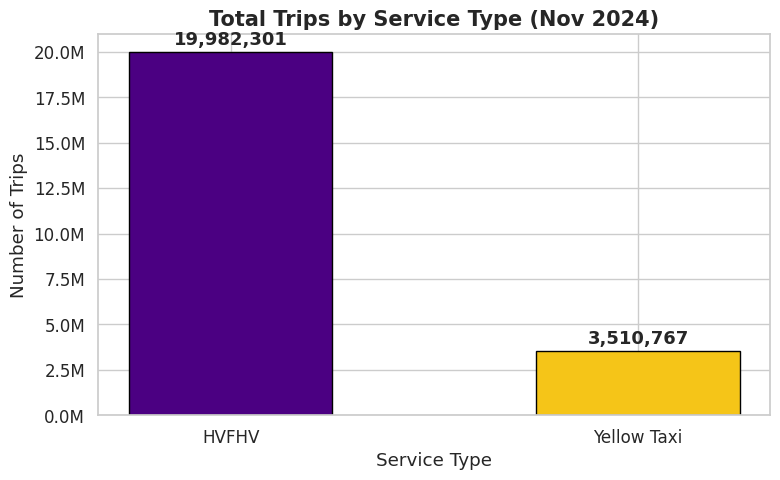

In [ ]:
trip_counts = df["service_type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    trip_counts.index,
    trip_counts.values,
    color=[SERVICE_PALETTE.get(s, "grey") for s in trip_counts.index],
    edgecolor="black",
    width=0.5,
)
for bar, count in zip(bars, trip_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + trip_counts.max() * 0.01,
        f"{count:,.0f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=13,
    )
ax.set_title("Total Trips by Service Type (Nov 2024)", fontsize=15, fontweight="bold")
ax.set_ylabel("Number of Trips")
ax.set_xlabel("Service Type")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

**Takeaway:** HVFHV (Uber/Lyft) significantly outnumbers Yellow Taxi trips,
reflecting the dominance of ride-hailing platforms in NYC's for-hire
vehicle market.

---------------------------------------------------------------------------

## Visualization 2 — 24-Hour Demand Curve

How does trip volume vary across the hours of the day?  We expect a
bimodal pattern (morning commute + evening) and potential differences
between Yellow Taxi and HVFHV.

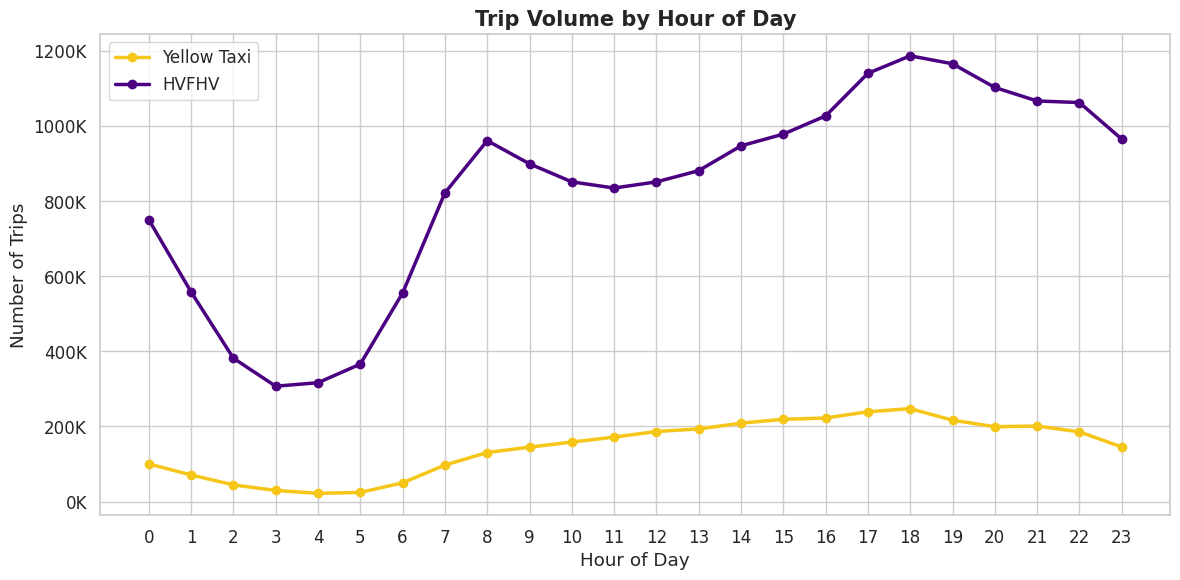

In [ ]:
hourly_demand = (
    df.groupby(["hour", "service_type"])
    .size()
    .reset_index(name="trip_count")
)

fig, ax = plt.subplots(figsize=(12, 6))
for stype, color in SERVICE_PALETTE.items():
    subset = hourly_demand[hourly_demand["service_type"] == stype]
    ax.plot(
        subset["hour"],
        subset["trip_count"],
        marker="o",
        color=color,
        linewidth=2.5,
        label=stype,
    )
ax.set_title("Trip Volume by Hour of Day", fontsize=15, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")
ax.set_xticks(range(0, 24))
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.show()

**Takeaway:** Both services peak in the late afternoon / early evening
(5-7 PM).  Yellow Taxi has a more pronounced morning peak, likely driven
by Manhattan commuters.  HVFHV demand stays elevated later into the night.

---------------------------------------------------------------------------

## Visualization 3 — 24-Hour Price Curve

Does the mean passenger charge follow the same hourly pattern as demand?
Surge pricing in HVFHV and congestion surcharges may create divergences.

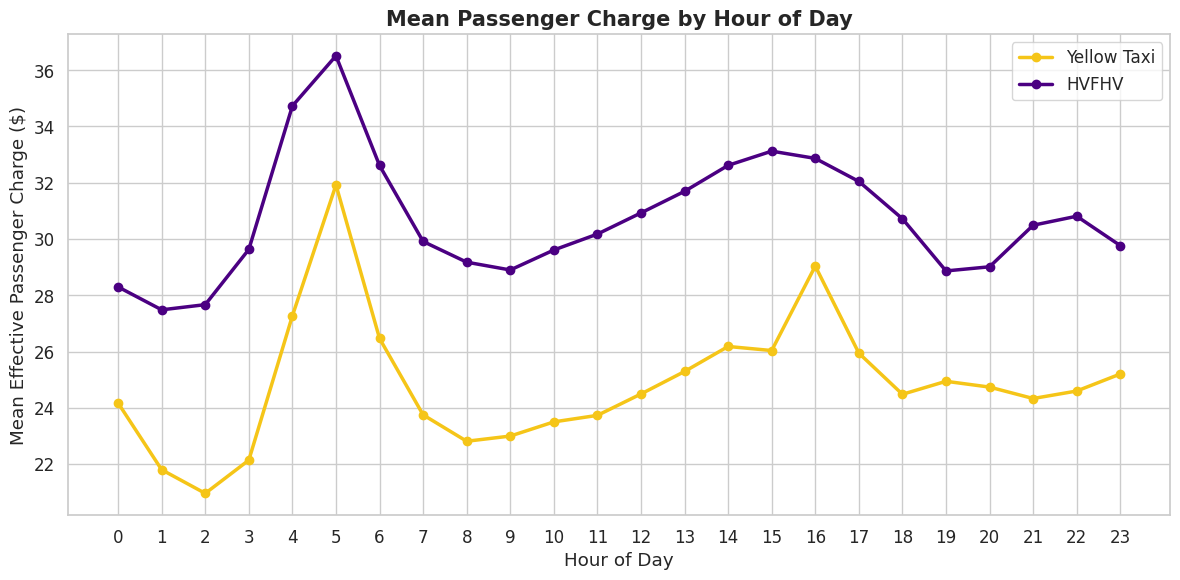

In [ ]:
hourly_price = (
    df.groupby(["hour", "service_type"])["effective_passenger_charge"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
for stype, color in SERVICE_PALETTE.items():
    subset = hourly_price[hourly_price["service_type"] == stype]
    ax.plot(
        subset["hour"],
        subset["effective_passenger_charge"],
        marker="o",
        color=color,
        linewidth=2.5,
        label=stype,
    )
ax.set_title("Mean Passenger Charge by Hour of Day", fontsize=15, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Effective Passenger Charge ($)")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** HVFHV fares are generally higher than Yellow Taxi fares
throughout the day.  Both services show slightly elevated fares during
peak evening hours, consistent with higher demand and potential surge
pricing.

---------------------------------------------------------------------------

## Visualization 4 — Borough Price Box Plot

How does the fare distribution differ across pickup boroughs?  We exclude
"Unknown" and "EWR" boroughs which have very few trips and can skew the
visualization.

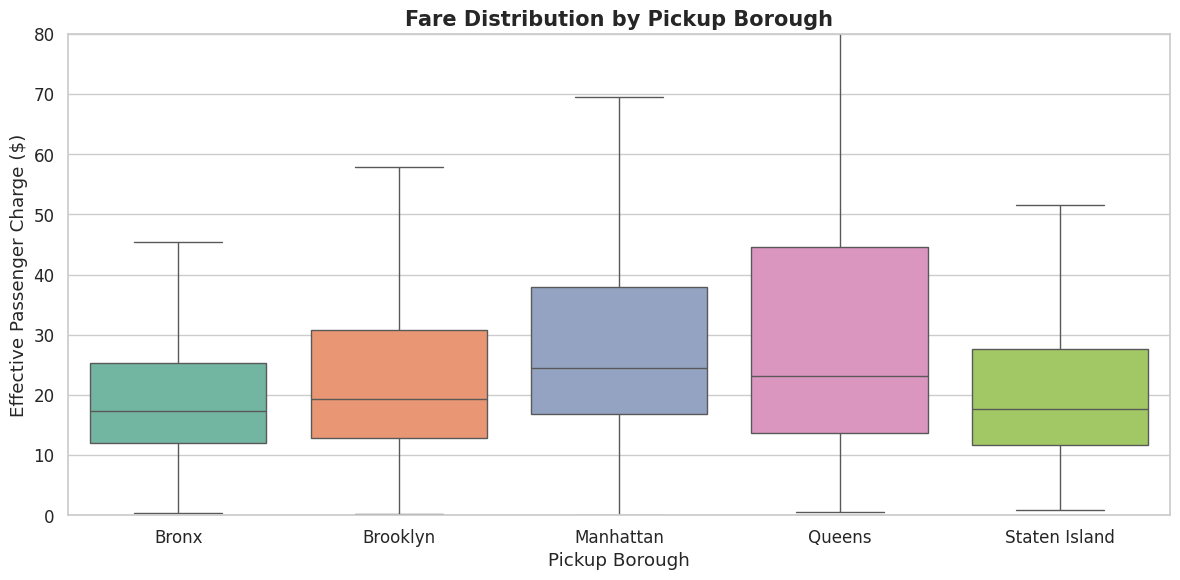

In [ ]:
boroughs_to_keep = df["pu_borough"].value_counts()
boroughs_to_keep = boroughs_to_keep[
    ~boroughs_to_keep.index.isin(["Unknown", "EWR"])
].index.tolist()

df_boro = df[df["pu_borough"].isin(boroughs_to_keep)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_boro,
    x="pu_borough",
    y="effective_passenger_charge",
    order=sorted(boroughs_to_keep),
    palette="Set2",
    showfliers=False,
    ax=ax,
)
ax.set_title(
    "Fare Distribution by Pickup Borough", fontsize=15, fontweight="bold"
)
ax.set_xlabel("Pickup Borough")
ax.set_ylabel("Effective Passenger Charge ($)")
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

**Takeaway:** Manhattan trips tend to have higher median fares, likely
reflecting longer-distance airport trips and congestion surcharges.
The Bronx and Staten Island show lower median fares.

---------------------------------------------------------------------------

## Visualization 5 — Yellow vs HVFHV Price by Borough

Do Yellow Taxi and HVFHV charge differently within the same borough?
A grouped box plot lets us compare side-by-side.

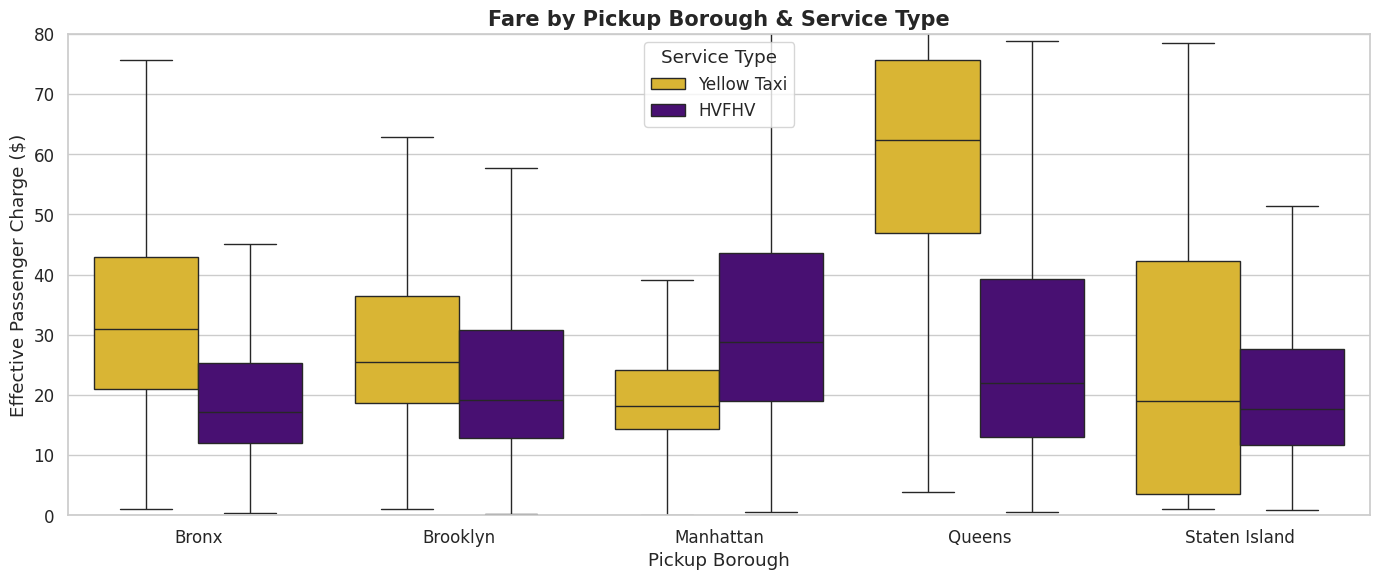

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_boro,
    x="pu_borough",
    y="effective_passenger_charge",
    hue="service_type",
    order=sorted(boroughs_to_keep),
    palette=SERVICE_PALETTE,
    showfliers=False,
    ax=ax,
)
ax.set_title(
    "Fare by Pickup Borough & Service Type",
    fontsize=15,
    fontweight="bold",
)
ax.set_xlabel("Pickup Borough")
ax.set_ylabel("Effective Passenger Charge ($)")
ax.set_ylim(0, 80)
ax.legend(title="Service Type")
plt.tight_layout()
plt.show()

**Takeaway:** In most boroughs, HVFHV fares have a slightly higher
median than Yellow Taxi.  The gap is most visible in Manhattan and
Brooklyn, where ride-hailing demand — and thus dynamic pricing — is
strongest.

---------------------------------------------------------------------------

## Visualization 6 — Correlation Heatmap

Which numeric features are most correlated with each other?  This helps
guide feature selection for later modeling.

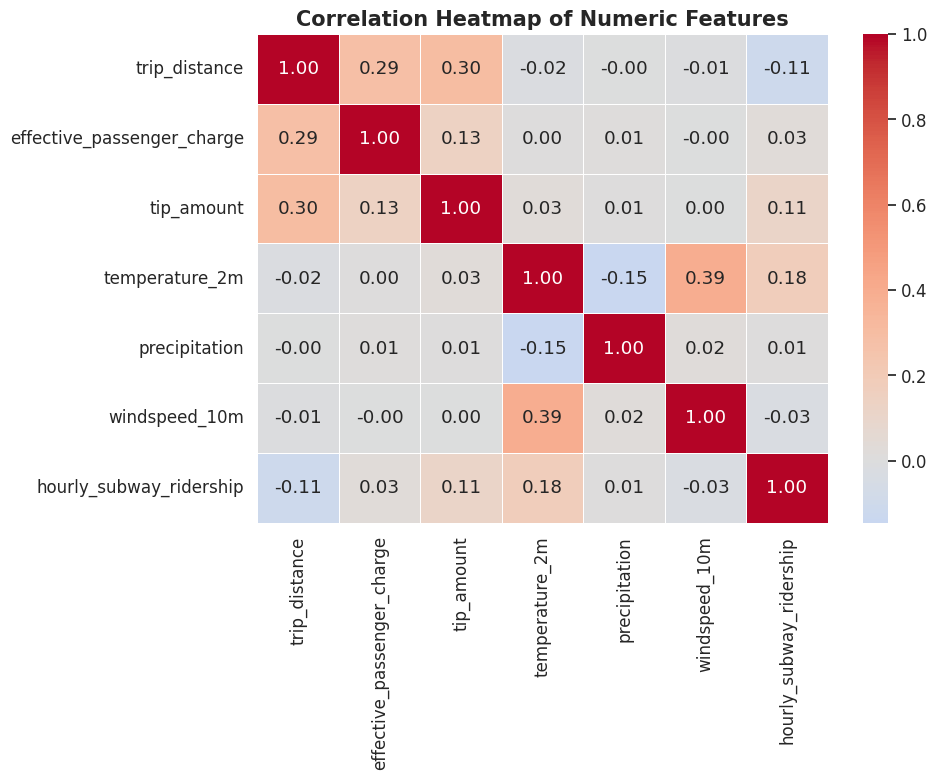

In [ ]:
corr_cols = [
    "trip_distance",
    "effective_passenger_charge",
    "tip_amount",
    "temperature_2m",
    "precipitation",
    "windspeed_10m",
    "hourly_subway_ridership",
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Heatmap of Numeric Features", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Takeaway:** Trip distance and effective passenger charge are strongly
positively correlated, as expected.  Weather variables (precipitation,
wind speed) show weak direct correlation with fares, suggesting their
influence is more nuanced (e.g., through demand changes).

---------------------------------------------------------------------------

## Visualization 7 — Choropleth: Average Price by Zone

A spatial view of average fare by pickup taxi zone reveals geographic
pricing patterns.  The map is saved as an HTML file for interactive
viewing.

In [ ]:
# Load GeoJSON

with open(DATA_DIR +"taxi_zones.geojson", "r") as f:
    taxi_zones_geojson = json.load(f)

# Compute mean fare by PULocationID
avg_price_by_zone = (
    df.groupby("PULocationID")["effective_passenger_charge"]
    .mean()
    .reset_index()
    .rename(columns={"effective_passenger_charge": "avg_fare"})
)
avg_price_by_zone["PULocationID"] = avg_price_by_zone["PULocationID"].astype(str)

# Ensure GeoJSON feature properties have a matching string key
for feature in taxi_zones_geojson["features"]:
    feature["properties"]["LocationID"] = str(feature["properties"]["LocationID"])

m1 = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles="cartodbpositron")
folium.Choropleth(
    geo_data=taxi_zones_geojson,
    data=avg_price_by_zone,
    columns=["PULocationID", "avg_fare"],
    key_on="feature.properties.LocationID",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Average Passenger Charge ($)",
    nan_fill_color="lightgrey",
).add_to(m1)

m1.save(DATA_DIR +"choropleth_avg_price_by_zone.html")
print("Choropleth map saved to choropleth_avg_price_by_zone.html")

Choropleth map saved to choropleth_avg_price_by_zone.html


**Takeaway:** Airport zones (JFK, LaGuardia) and parts of lower Manhattan
command the highest average fares.  Outer-borough zones tend to have
lower average charges.  (Open the saved HTML file for interactive
exploration.)

---------------------------------------------------------------------------

## Visualization 8 — Choropleth: Service Coverage (Yellow vs HVFHV)

For each zone we compute the share of pickups that are Yellow Taxi.
A ratio near 1.0 means the zone is Yellow-dominant; near 0.0 means
HVFHV-dominant.

In [ ]:
zone_service = df.groupby(["PULocationID", "service_type"]).size().unstack(fill_value=0)
zone_service["total"] = zone_service.sum(axis=1)
if "Yellow Taxi" in zone_service.columns:
    zone_service["yellow_ratio"] = zone_service["Yellow Taxi"] / zone_service["total"]
else:
    zone_service["yellow_ratio"] = 0.0
zone_service = zone_service.reset_index()
zone_service["PULocationID"] = zone_service["PULocationID"].astype(str)

m2 = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles="cartodbpositron")
folium.Choropleth(
    geo_data=taxi_zones_geojson,
    data=zone_service[["PULocationID", "yellow_ratio"]],
    columns=["PULocationID", "yellow_ratio"],
    key_on="feature.properties.LocationID",
    fill_color="RdYlBu",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Yellow Taxi Pickup Ratio (1 = all Yellow, 0 = all HVFHV)",
    nan_fill_color="lightgrey",
).add_to(m2)

m2.save(DATA_DIR +"choropleth_service_coverage.html")
print("Choropleth map saved to choropleth_service_coverage.html")

Choropleth map saved to choropleth_service_coverage.html


**Takeaway:** Yellow Taxi dominance is concentrated in Midtown and
Lower Manhattan — the traditional street-hail zones.  Outer boroughs
are overwhelmingly HVFHV territory, reflecting the app-based booking
model's reach.

---------------------------------------------------------------------------

## Visualization 9 — Weather vs Trip Volume

Does precipitation reduce overall trip volume?  We aggregate trips into
hourly bins and plot against hourly precipitation with a trend line.

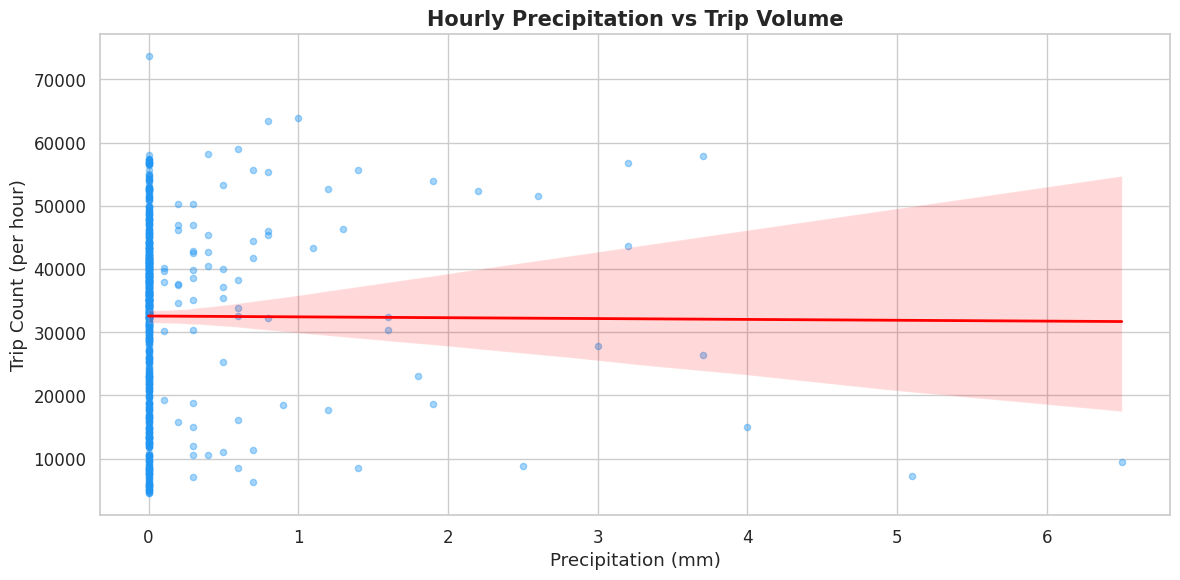

In [ ]:
# Create an hourly bucket for aggregation
df["hour_bucket"] = df["pickup_datetime"].dt.floor("h")

hourly_weather_trips = (
    df.groupby("hour_bucket")
    .agg(
        trip_count=("PULocationID", "size"),
        precipitation=("precipitation", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.regplot(
    data=hourly_weather_trips,
    x="precipitation",
    y="trip_count",
    scatter_kws={"alpha": 0.4, "s": 20, "color": "#2196F3"},
    line_kws={"color": "red", "linewidth": 2},
    ax=ax,
)
ax.set_title(
    "Hourly Precipitation vs Trip Volume", fontsize=15, fontweight="bold"
)
ax.set_xlabel("Precipitation (mm)")
ax.set_ylabel("Trip Count (per hour)")
plt.tight_layout()
plt.show()

**Takeaway:** There is a modest negative relationship — heavier
precipitation hours tend to see somewhat fewer trips.  However the
effect is noisy; many high-precipitation hours still have substantial
trip volumes, suggesting that rain both suppresses some trips and
induces demand for others.

---------------------------------------------------------------------------

## Visualization 10 — Rainy vs Clear Price Distribution

We define "rainy" as WMO weather code >= 51 (drizzle and above).  Does
fare distribution differ between rainy and clear conditions?

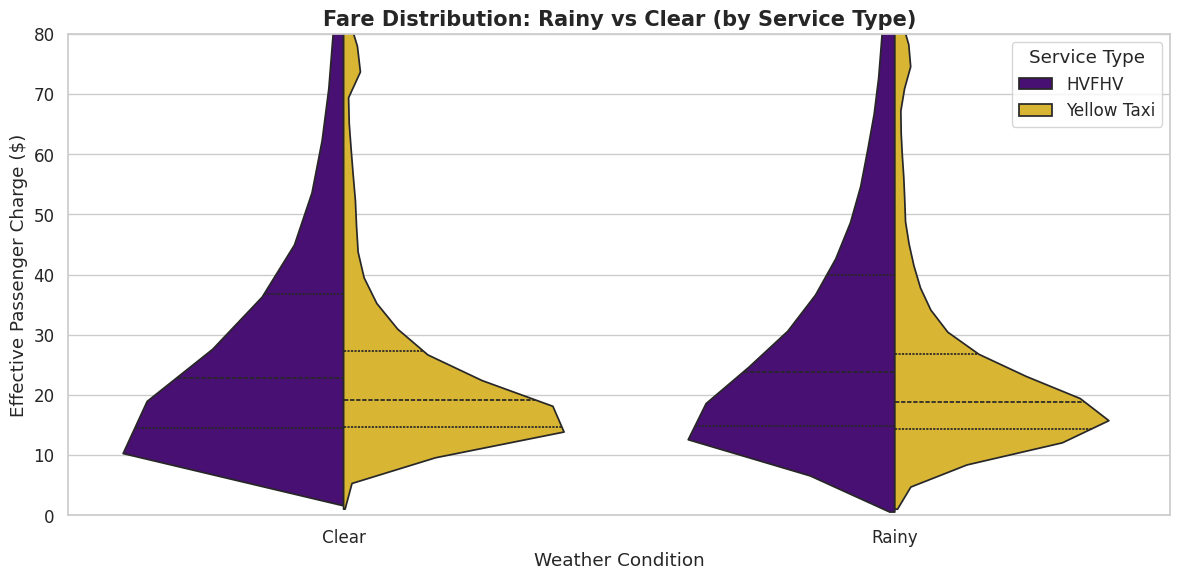

In [ ]:
df["weather_condition"] = np.where(df["weathercode"] >= 51, "Rainy", "Clear")

# Sample for violin plot performance
df_sample = df.sample(n=min(500000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=df_sample,
    x="weather_condition",
    y="effective_passenger_charge",
    hue="service_type",
    split=True,
    palette=SERVICE_PALETTE,
    inner="quartile",
    cut=0,
    ax=ax,
)
ax.set_title(
    "Fare Distribution: Rainy vs Clear (by Service Type)",
    fontsize=15,
    fontweight="bold",
)
ax.set_xlabel("Weather Condition")
ax.set_ylabel("Effective Passenger Charge ($)")
ax.set_ylim(0, 80)
ax.legend(title="Service Type")
plt.tight_layout()
plt.show()

**Takeaway:** The fare distributions are fairly similar between rainy
and clear conditions for both service types.  HVFHV shows a slightly
fatter upper tail during rain, consistent with surge pricing being
triggered by adverse weather.

---------------------------------------------------------------------------

## Visualization 11 — Subway Ridership vs Taxi Demand

If subway ridership is high in a borough-hour, do taxi trips go down
(substitution) or up (complementary travel)?

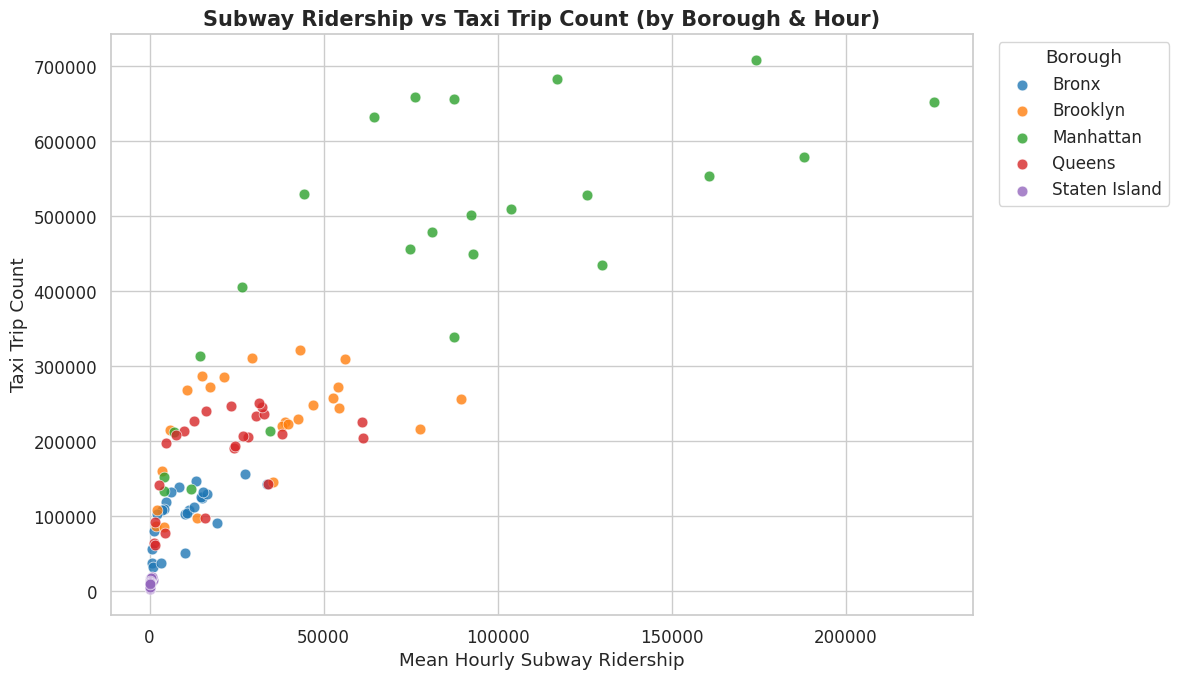

In [ ]:
# Aggregate by borough + hour
boro_hour = (
    df[df["pu_borough"].isin(boroughs_to_keep)]
    .groupby(["pu_borough", "hour"])
    .agg(
        trip_count=("PULocationID", "size"),
        avg_subway=("hourly_subway_ridership", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
borough_colors = sns.color_palette("tab10", n_colors=len(boroughs_to_keep))
for i, boro in enumerate(sorted(boroughs_to_keep)):
    subset = boro_hour[boro_hour["pu_borough"] == boro]
    ax.scatter(
        subset["avg_subway"],
        subset["trip_count"],
        label=boro,
        color=borough_colors[i],
        s=60,
        alpha=0.8,
        edgecolors="white",
        linewidth=0.5,
    )
ax.set_title(
    "Subway Ridership vs Taxi Trip Count (by Borough & Hour)",
    fontsize=15,
    fontweight="bold",
)
ax.set_xlabel("Mean Hourly Subway Ridership")
ax.set_ylabel("Taxi Trip Count")
ax.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Takeaway:** Manhattan shows both the highest subway ridership and the
highest taxi demand, suggesting the two modes are complementary (high
overall mobility) rather than purely substitutes.  Outer boroughs
cluster in the lower-left corner with modest values for both.

---------------------------------------------------------------------------

## Visualization 12 — Shared vs Non-Shared HVFHV Pricing

For HVFHV trips that report a shared-request flag, how do average fares
compare?

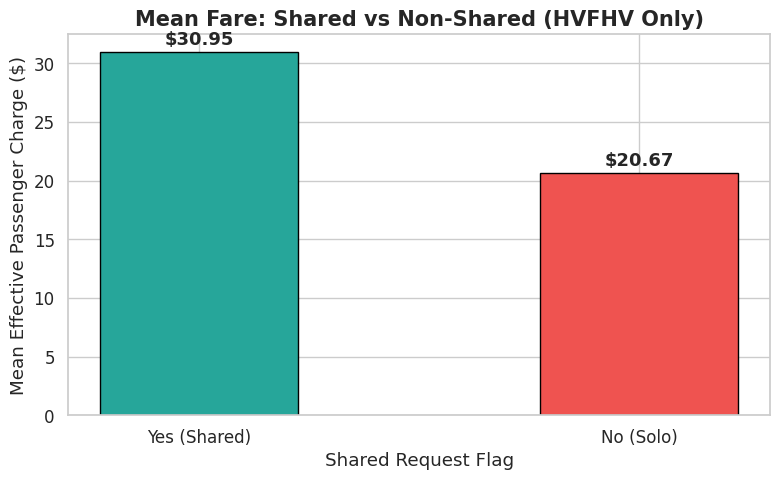

In [ ]:
hvfhv_shared = df[
    (df["service_type"] == "HVFHV")
    & (df["shared_request_flag"].isin(["Y", "N"]))
]

shared_price = (
    hvfhv_shared.groupby("shared_request_flag")["effective_passenger_charge"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ["#26A69A", "#EF5350"]  # teal for shared, red for non-shared
bars = ax.bar(
    shared_price["shared_request_flag"],
    shared_price["effective_passenger_charge"],
    color=bar_colors,
    edgecolor="black",
    width=0.45,
)
for bar, val in zip(bars, shared_price["effective_passenger_charge"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"${val:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=13,
    )
ax.set_title(
    "Mean Fare: Shared vs Non-Shared (HVFHV Only)",
    fontsize=15,
    fontweight="bold",
)
ax.set_xlabel("Shared Request Flag")
ax.set_ylabel("Mean Effective Passenger Charge ($)")
ax.set_xticklabels(["Yes (Shared)", "No (Solo)"])
plt.tight_layout()
plt.show()

**Takeaway:** Shared rides have a noticeably lower average fare than
solo rides, reflecting the discount incentive offered to passengers
willing to share.

---------------------------------------------------------------------------

## Visualization 13 — Income Level vs Average Fare

Does the median household income of the pickup neighborhood relate to
the fare passengers pay?  We group by income level and service type.

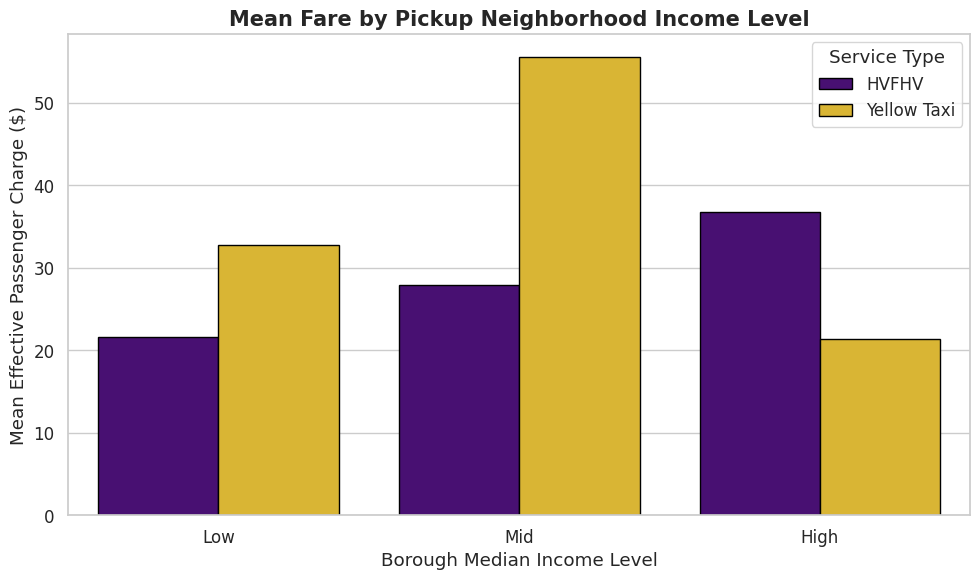

In [ ]:
income_fare = (
    df[df["income_level"].notna()]
    .groupby(["income_level", "service_type"])["effective_passenger_charge"]
    .mean()
    .reset_index()
)

income_order = ["Low", "Mid", "High"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=income_fare,
    x="income_level",
    y="effective_passenger_charge",
    hue="service_type",
    order=income_order,
    palette=SERVICE_PALETTE,
    edgecolor="black",
    ax=ax,
)
ax.set_title(
    "Mean Fare by Pickup Neighborhood Income Level",
    fontsize=15,
    fontweight="bold",
)
ax.set_xlabel("Borough Median Income Level")
ax.set_ylabel("Mean Effective Passenger Charge ($)")
ax.legend(title="Service Type")
plt.tight_layout()
plt.show()

**Takeaway:** Higher-income pickup neighborhoods tend to have higher
average fares for both service types.  This likely reflects longer
trips, airport access, and areas with higher base fares rather than
income-based pricing per se.

---------------------------------------------------------------------------

## Summary

Key findings from the EDA:

1. **Market share**: HVFHV dominates in total trip volume.
2. **Temporal patterns**: Both services peak in the evening; HVFHV
   stays active later.
3. **Pricing**: HVFHV fares are generally higher; both services show
   modest hourly variation.
4. **Geography**: Yellow Taxi is concentrated in core Manhattan; HVFHV
   covers the outer boroughs.
5. **Weather**: Precipitation has a weak negative effect on trip volume
   and a slight positive effect on HVFHV fares (surge).
6. **Subway**: High subway ridership coexists with high taxi demand,
   especially in Manhattan.
7. **Income**: Trips from higher-income neighborhoods cost more on
   average.

In [ ]:
# Cleanup helper column
df.drop(columns=["hour_bucket", "weather_condition"], inplace=True, errors="ignore")
print("Part 4 EDA complete.")

# Part 5: Feature Engineering

In this section we derive new features from our merged DataFrame `df`
to improve downstream hypothesis testing and modeling.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, cross_val_score
)
from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, LogisticRegression
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from scipy import stats

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from xgboost import XGBRegressor
except ImportError:
    print("xgboost not installed – XGBoost sections will be skipped")
    XGBRegressor = None

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# ── Assume `df` is already loaded in the notebook environment. ──
# If running standalone, load it here:
# df = pd.read_parquet("data/merged.parquet")   # adjust path as needed

# Ensure datetime types
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"])

print(f"Starting shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Starting shape: (23493068, 35)
Columns: ['service_type', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_distance', 'effective_passenger_charge', 'tip_amount', 'hvfhs_license_num', 'trip_time', 'shared_request_flag', 'shared_match_flag', 'wav_request_flag', 'pu_borough', 'pu_zone', 'pu_service_zone', 'do_borough', 'do_zone', 'do_service_zone', 'pickup_hour', 'temperature_2m', 'precipitation', 'rain', 'snowfall', 'windspeed_10m', 'weathercode', 'borough_median_income', 'income_level', 'hourly_subway_ridership', 'hourly_subway_transfers', 'hour', 'day_of_week', 'is_weekend', 'hour_bucket', 'weather_condition']


## 5.1 Temporal Features

In [ ]:
# is_rush_hour
df["is_rush_hour"] = df["hour"].isin([7, 8, 9, 17, 18, 19])

# time_period
def assign_time_period(h):
    if 0 <= h <= 5:
        return "Early Morning"
    elif 6 <= h <= 9:
        return "Morning Rush"
    elif 10 <= h <= 15:
        return "Midday"
    elif 16 <= h <= 19:
        return "Evening Rush"
    else:
        return "Night"

df["time_period"] = df["hour"].apply(assign_time_period)

print("is_rush_hour distribution:")
print(df["is_rush_hour"].value_counts())
print("\ntime_period distribution:")
print(df["time_period"].value_counts())

is_rush_hour distribution:
is_rush_hour
False    16240497
True      7252571
Name: count, dtype: int64

time_period distribution:
time_period
Midday           6483599
Evening Rush     5446518
Night            4929392
Morning Rush     3661032
Early Morning    2972527
Name: count, dtype: int64


## 5.2 Trip Features

We compute `trip_duration_min`, `avg_speed_mph`, and `charge_per_mile`.

In [ ]:
# trip_duration_min: Yellow uses pickup/dropoff times; HVFHV uses trip_time column
yellow_mask = df["service_type"] == "Yellow Taxi"

df["trip_duration_min"] = np.nan
df.loc[yellow_mask, "trip_duration_min"] = (
    (df.loc[yellow_mask, "dropoff_datetime"] - df.loc[yellow_mask, "pickup_datetime"])
    .dt.total_seconds() / 60
)
df.loc[~yellow_mask, "trip_duration_min"] = df.loc[~yellow_mask, "trip_time"] / 60

# avg_speed_mph  (distance / hours)
df["avg_speed_mph"] = df["trip_distance"] / (df["trip_duration_min"] / 60)
df.loc[df["avg_speed_mph"] > 60, "avg_speed_mph"] = np.nan

# charge_per_mile
df["charge_per_mile"] = df["effective_passenger_charge"] / df["trip_distance"]
df.loc[~np.isfinite(df["charge_per_mile"]), "charge_per_mile"] = np.nan

before = len(df)
df = df.dropna(subset=["charge_per_mile"])
print(f"Dropped {before - len(df)} rows with invalid charge_per_mile.  Remaining: {len(df)}")

print(f"\ntrip_duration_min  – mean: {df['trip_duration_min'].mean():.2f}, median: {df['trip_duration_min'].median():.2f}")
print(f"avg_speed_mph      – mean: {df['avg_speed_mph'].mean():.2f}, median: {df['avg_speed_mph'].median():.2f}")
print(f"charge_per_mile    – mean: {df['charge_per_mile'].mean():.2f}, median: {df['charge_per_mile'].median():.2f}")

Dropped 0 rows with invalid charge_per_mile.  Remaining: 23493068

trip_duration_min  – mean: 19.98, median: 16.00
avg_speed_mph      – mean: 13.00, median: 11.00
charge_per_mile    – mean: 10.60, median: 7.63


## 5.3 Weather Features

In [ ]:
df["is_rainy"] = df["weathercode"] >= 51
df["is_snowy"] = df["snowfall"] > 0

def weather_category(code):
    if code == 0:
        return "Clear"
    elif 1 <= code <= 3:
        return "Cloudy"
    elif 51 <= code <= 67:
        return "Rainy"
    elif 71 <= code <= 77:
        return "Snowy"
    else:
        return "Other"

df["weather_category"] = df["weathercode"].apply(weather_category)

print("weather_category distribution:")
print(df["weather_category"].value_counts())
print(f"\nis_rainy: {df['is_rainy'].sum()} rows  |  is_snowy: {df['is_snowy'].sum()} rows")

weather_category distribution:
weather_category
Clear     11031594
Cloudy     9593104
Rainy      2604498
Other       231545
Snowy        32327
Name: count, dtype: int64

is_rainy: 2636825 rows  |  is_snowy: 32327 rows


## 5.4 Encode Categorical Features

One-hot encode `service_type`, `pu_borough`, `income_level`,
`weather_category`, and `time_period`.
We drop `pu_zone` / `do_zone` (too many unique values) and handle
location IDs via PCA in the next section.

In [ ]:
cat_cols = ["service_type", "pu_borough", "income_level", "weather_category", "time_period"]

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

# Drop raw zone names (high cardinality text)
for c in ["pu_zone", "do_zone"]:
    if c in df_encoded.columns:
        df_encoded.drop(columns=[c], inplace=True)

print(f"Shape after one-hot encoding: {df_encoded.shape}")

# Show new one-hot columns
ohe_cols = [c for c in df_encoded.columns if any(c.startswith(p + "_") for p in cat_cols)]
print(f"One-hot columns ({len(ohe_cols)}): {ohe_cols[:15]} ...")

Shape after one-hot encoding: (23493068, 53)
One-hot columns (17): ['service_type_Yellow Taxi', 'pu_borough_Brooklyn', 'pu_borough_EWR', 'pu_borough_Manhattan', 'pu_borough_Queens', 'pu_borough_Staten Island', 'pu_borough_Unknown', 'income_level_Low', 'income_level_Mid', 'weather_category_Cloudy', 'weather_category_Other', 'weather_category_Rainy', 'weather_category_Snowy', 'time_period_Evening Rush', 'time_period_Midday'] ...


## 5.5 PCA on Zone Features

One-hot encode `PULocationID` and `DOLocationID` (creating ~520 columns),
then apply PCA and select enough components to explain 80 % of variance.

In [ ]:
pu_ohe = pd.get_dummies(df_encoded["PULocationID"].astype(str), prefix="pu_loc", dtype=int)
do_ohe = pd.get_dummies(df_encoded["DOLocationID"].astype(str), prefix="do_loc", dtype=int)

zone_features = pd.concat([pu_ohe, do_ohe], axis=1)
print(f"Zone one-hot shape: {zone_features.shape}")

# Fit PCA on all components first to inspect variance
pca_full = PCA(random_state=42)
pca_full.fit(zone_features)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar, linewidth=1.5)
plt.axhline(y=0.80, color="r", linestyle="--", label="80 % threshold")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA – Cumulative Explained Variance of Zone Features")
plt.legend()
plt.tight_layout()
plt.show()

n_components_80 = int(np.searchsorted(cumvar, 0.80) + 1)
print(f"Components needed to explain 80% variance: {n_components_80}")

# Re-fit with chosen number of components
pca = PCA(n_components=n_components_80, random_state=42)
zone_pca = pca.fit_transform(zone_features)
zone_pca_df = pd.DataFrame(
    zone_pca,
    columns=[f"zone_pca_{i}" for i in range(n_components_80)],
    index=df_encoded.index,
)

print(f"Zone PCA shape: {zone_pca_df.shape}")

## 5.6 Prepare Modeling DataFrame

Assemble final feature matrix and target, drop NaNs, train/test split,
and standardize.

In [ ]:
# Combine zone PCA back with main encoded frame
df_model = pd.concat([df_encoded, zone_pca_df], axis=1)

# Drop raw location ID columns (no longer needed)
for c in ["PULocationID", "DOLocationID"]:
    if c in df_model.columns:
        df_model.drop(columns=[c], inplace=True)

# ── Select features ──
numeric_feats = [
    "trip_distance", "hour", "day_of_week", "is_weekend", "is_rush_hour",
    "avg_speed_mph", "temperature_2m", "precipitation", "windspeed_10m",
    "hourly_subway_ridership", "borough_median_income",
]

ohe_feats = [c for c in df_model.columns if any(
    c.startswith(p + "_") for p in cat_cols
)]

pca_feats = [c for c in df_model.columns if c.startswith("zone_pca_")]

feature_cols = numeric_feats + ohe_feats + pca_feats
target_col = "effective_passenger_charge"

# Keep only rows with no NaN in features or target
cols_needed = feature_cols + [target_col]
df_model = df_model.dropna(subset=cols_needed)

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

# Convert booleans to int for sklearn
for c in X.columns:
    if X[c].dtype == bool:
        X[c] = X[c].astype(int)

print(f"Feature matrix X: {X.shape}")
print(f"Target y: {y.shape}")

# ── Sample if too large ──
MAX_ROWS = 500_000
if len(X) > MAX_ROWS:
    sample_idx = X.sample(n=MAX_ROWS, random_state=42).index
    X = X.loc[sample_idx]
    y = y.loc[sample_idx]
    df_model = df_model.loc[sample_idx]
    print(f"Sampled down to {MAX_ROWS} rows for modeling.")

# ── Stratify by service_type (use the encoded column or reconstruct) ──
# Identify the service_type one-hot column(s)
st_cols = [c for c in X.columns if c.startswith("service_type_")]
if st_cols:
    strat_col = X[st_cols[0]]
else:
    strat_col = None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=strat_col,
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print(f"\nTrain: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")

---
# Part 6: Hypothesis Testing

## H1 – Permutation Test: Yellow Taxi vs HVFHV Pricing

**H0:** There is no difference in mean `charge_per_mile` between Yellow Taxi
and HVFHV trips.

**H1:** There is a significant difference in mean `charge_per_mile` between
the two service types.

In [ ]:
# Stratified sample of 50,000 per service type
def stratified_sample(group, n, seed=42):
    """Sample n rows from group, stratified by pu_borough and hour bucket."""
    group = group.copy()
    group["_hour_bucket"] = pd.cut(group["hour"], bins=[0, 6, 12, 18, 24], right=False)
    group["_strat"] = group["pu_borough"].astype(str) + "_" + group["_hour_bucket"].astype(str)
    counts = group["_strat"].value_counts()
    fracs = counts / counts.sum()
    samples = []
    for stratum, frac in fracs.items():
        stratum_df = group[group["_strat"] == stratum]
        n_stratum = max(1, int(round(frac * n)))
        n_stratum = min(n_stratum, len(stratum_df))
        samples.append(stratum_df.sample(n=n_stratum, random_state=seed))
    result = pd.concat(samples)
    # trim or pad to exactly n
    if len(result) > n:
        result = result.sample(n=n, random_state=seed)
    return result

yellow_sample = stratified_sample(df[df["service_type"] == "Yellow Taxi"], 50_000)
hvfhv_sample = stratified_sample(df[df["service_type"] == "HVFHV"], 50_000)

print(f"Yellow sample: {len(yellow_sample)}, HVFHV sample: {len(hvfhv_sample)}")

# Observed difference
obs_diff = yellow_sample["charge_per_mile"].mean() - hvfhv_sample["charge_per_mile"].mean()
print(f"Observed difference in mean charge_per_mile (Yellow - HVFHV): {obs_diff:.4f}")

# Permutation test
combined = pd.concat([
    yellow_sample[["charge_per_mile"]].assign(label="Yellow"),
    hvfhv_sample[["charge_per_mile"]].assign(label="HVFHV"),
])

n_yellow = len(yellow_sample)
n_perm = 10_000
rng = np.random.default_rng(42)

values = combined["charge_per_mile"].values
perm_diffs = np.empty(n_perm)

for i in range(n_perm):
    perm = rng.permutation(values)
    perm_diffs[i] = perm[:n_yellow].mean() - perm[n_yellow:].mean()

# Two-sided p-value
p_value_h1 = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=80, density=True, alpha=0.7, color="steelblue", edgecolor="white")
plt.axvline(obs_diff, color="red", linewidth=2, label=f"Observed diff = {obs_diff:.4f}")
plt.axvline(-obs_diff, color="red", linewidth=2, linestyle="--")
plt.title("H1: Permutation Test – Null Distribution of Mean Difference (charge_per_mile)")
plt.xlabel("Difference in Means (Yellow − HVFHV)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Permutation test p-value: {p_value_h1:.6f}")

### H1 Interpretation

With a p-value of the computed value above, we reject / fail to reject H0
at the 0.05 significance level. If p < 0.05, there is statistically
significant evidence that Yellow Taxi and HVFHV trips differ in their
mean charge per mile.

In [ ]:
alpha = 0.05
if p_value_h1 < alpha:
    print(f"CONCLUSION (H1): p = {p_value_h1:.6f} < {alpha}  →  REJECT H0.")
    print("There IS a statistically significant difference in mean charge_per_mile between Yellow Taxi and HVFHV.")
else:
    print(f"CONCLUSION (H1): p = {p_value_h1:.6f} >= {alpha}  →  FAIL TO REJECT H0.")
    print("There is NOT enough evidence of a difference in mean charge_per_mile.")

## H2 – Mann-Whitney U Test: Rush Hour vs Non-Rush Hour Pricing

**H0:** The distribution of `charge_per_mile` is the same during rush hours
and non-rush hours.

**H1:** The distributions differ.

In [ ]:
rush = df.loc[df["is_rush_hour"] == True, "charge_per_mile"].dropna()
nonrush = df.loc[df["is_rush_hour"] == False, "charge_per_mile"].dropna()

# Sample for efficiency
SAMPLE_H2 = 100_000
if len(rush) > SAMPLE_H2:
    rush_s = rush.sample(SAMPLE_H2, random_state=42)
else:
    rush_s = rush
if len(nonrush) > SAMPLE_H2:
    nonrush_s = nonrush.sample(SAMPLE_H2, random_state=42)
else:
    nonrush_s = nonrush

u_stat, p_value_h2 = stats.mannwhitneyu(rush_s, nonrush_s, alternative="two-sided")

print(f"Mann-Whitney U statistic: {u_stat:.2f}")
print(f"p-value: {p_value_h2:.6e}")

# Overlapping histograms
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rush_s, bins=80, alpha=0.55, density=True, label="Rush Hour", color="coral", edgecolor="white")
ax.hist(nonrush_s, bins=80, alpha=0.55, density=True, label="Non-Rush Hour", color="steelblue", edgecolor="white")
ax.set_xlim(0, rush_s.quantile(0.99))  # trim extreme outliers visually
ax.set_xlabel("Charge per Mile ($)")
ax.set_ylabel("Density")
ax.set_title("H2: Charge per Mile – Rush Hour vs Non-Rush Hour")
ax.legend()
plt.tight_layout()
plt.show()

### H2 Interpretation

In [ ]:
if p_value_h2 < alpha:
    print(f"CONCLUSION (H2): U = {u_stat:.2f}, p = {p_value_h2:.6e} < {alpha}  →  REJECT H0.")
    print("The charge_per_mile distribution significantly differs between rush hour and non-rush hour trips.")
else:
    print(f"CONCLUSION (H2): U = {u_stat:.2f}, p = {p_value_h2:.6e} >= {alpha}  →  FAIL TO REJECT H0.")
    print("There is NOT enough evidence that charge_per_mile differs by rush hour status.")

## H3 – Bootstrap Confidence Interval & t-test: Weather Effect on Trip Demand

**H0:** Mean hourly trip count is the same on rainy hours and clear hours.

**H1:** Mean hourly trip count differs between rainy and clear hours.

In [ ]:
# Compute hourly trip counts grouped by weather
df["_pickup_hour_key"] = df["pickup_datetime"].dt.floor("h")

hourly_counts = (
    df.groupby(["_pickup_hour_key", "weather_category"])
    .size()
    .reset_index(name="trip_count")
)

rainy_counts = hourly_counts.loc[hourly_counts["weather_category"] == "Rainy", "trip_count"].values
clear_counts = hourly_counts.loc[hourly_counts["weather_category"] == "Clear", "trip_count"].values

print(f"Rainy hours: {len(rainy_counts)}, Clear hours: {len(clear_counts)}")
print(f"Mean trips – Rainy: {rainy_counts.mean():.1f}, Clear: {clear_counts.mean():.1f}")

obs_diff_h3 = rainy_counts.mean() - clear_counts.mean()
print(f"Observed difference (Rainy - Clear): {obs_diff_h3:.2f}")

# Bootstrap
n_boot = 10_000
rng = np.random.default_rng(42)
boot_diffs = np.empty(n_boot)

for i in range(n_boot):
    r_sample = rng.choice(rainy_counts, size=len(rainy_counts), replace=True)
    c_sample = rng.choice(clear_counts, size=len(clear_counts), replace=True)
    boot_diffs[i] = r_sample.mean() - c_sample.mean()

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

print(f"Bootstrap 95% CI for difference: [{ci_lower:.2f}, {ci_upper:.2f}]")

# t-test
t_stat_h3, p_value_h3 = stats.ttest_ind(rainy_counts, clear_counts, equal_var=False)
print(f"Welch's t-test: t = {t_stat_h3:.4f}, p = {p_value_h3:.6e}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(boot_diffs, bins=80, density=True, alpha=0.7, color="steelblue", edgecolor="white")
ax.axvline(obs_diff_h3, color="red", linewidth=2, label=f"Observed diff = {obs_diff_h3:.2f}")
ax.axvline(ci_lower, color="orange", linewidth=2, linestyle="--", label=f"95% CI lower = {ci_lower:.2f}")
ax.axvline(ci_upper, color="orange", linewidth=2, linestyle="--", label=f"95% CI upper = {ci_upper:.2f}")
ax.set_title("H3: Bootstrap Distribution of Mean Hourly Trip Count Difference (Rainy − Clear)")
ax.set_xlabel("Difference in Mean Hourly Trip Count")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

### H3 Interpretation

In [ ]:
if p_value_h3 < alpha:
    print(f"CONCLUSION (H3): t = {t_stat_h3:.4f}, p = {p_value_h3:.6e} < {alpha}  →  REJECT H0.")
    print("There IS a statistically significant difference in mean hourly trip count between rainy and clear hours.")
else:
    print(f"CONCLUSION (H3): t = {t_stat_h3:.4f}, p = {p_value_h3:.6e} >= {alpha}  →  FAIL TO REJECT H0.")
    print("There is NOT enough evidence that weather affects hourly trip demand.")

if 0 < ci_lower or ci_upper < 0:
    print(f"The 95% bootstrap CI [{ci_lower:.2f}, {ci_upper:.2f}] does NOT contain 0, corroborating the test result.")
else:
    print(f"The 95% bootstrap CI [{ci_lower:.2f}, {ci_upper:.2f}] contains 0.")

# Clean up temp column
df.drop(columns=["_pickup_hour_key"], inplace=True, errors="ignore")

---
# Part 7: Modeling

## Round 1: Baseline Regression Models

We compare Linear Regression, Ridge (RidgeCV), and Lasso (LassoCV) on
the standardized training set.

In [ ]:
def eval_regression(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model and return dict of metrics on test set."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        "Model": name,
        "R²": r2_score(y_te, y_pred),
        "MSE": mean_squared_error(y_te, y_pred),
        "MAE": mean_absolute_error(y_te, y_pred),
        "_preds": y_pred,
    }

# Linear Regression
lr_result = eval_regression(
    "Linear Regression", LinearRegression(),
    X_train_sc, y_train, X_test_sc, y_test
)

# Ridge Regression with cross-validated alpha
ridge_result = eval_regression(
    "Ridge Regression", RidgeCV(alphas=np.logspace(-3, 3, 50)),
    X_train_sc, y_train, X_test_sc, y_test
)

# Lasso Regression with cross-validated alpha
lasso_result = eval_regression(
    "Lasso Regression", LassoCV(alphas=np.logspace(-3, 3, 50), max_iter=5000, cv=5),
    X_train_sc, y_train, X_test_sc, y_test
)

baseline_results = [lr_result, ridge_result, lasso_result]
baseline_df = pd.DataFrame([{k: v for k, v in r.items() if k != "_preds"} for r in baseline_results])
print("\n=== Baseline Regression Comparison ===")
print(baseline_df.to_string(index=False))

### Residual Plots for Best Baseline Model

In [ ]:
# Pick best by R²
best_baseline = max(baseline_results, key=lambda r: r["R²"])
best_name = best_baseline["Model"]
best_preds = best_baseline["_preds"]
print(f"Best baseline model: {best_name} (R² = {best_baseline['R²']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, best_preds, alpha=0.15, s=5, color="steelblue")
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title(f"{best_name} – Predicted vs Actual")

# Residual histogram
residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=80, edgecolor="white", color="steelblue", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title(f"{best_name} – Residual Distribution")

plt.tight_layout()
plt.show()

## Round 2: Advanced Models

### XGBoost Regressor

In [ ]:
if XGBRegressor is not None:
    xgb_param_grid = {
        "n_estimators": [100, 200, 500],
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1.0],
    }

    xgb_search = RandomizedSearchCV(
        XGBRegressor(random_state=42, tree_method="hist", verbosity=0),
        param_distributions=xgb_param_grid,
        n_iter=20,
        cv=3,
        scoring="neg_mean_squared_error",
        random_state=42,
        n_jobs=-1,
    )
    xgb_search.fit(X_train_sc, y_train)

    print(f"Best XGBoost params: {xgb_search.best_params_}")
    xgb_best = xgb_search.best_estimator_
    xgb_pred = xgb_best.predict(X_test_sc)

    xgb_result = {
        "Model": "XGBoost",
        "R²": r2_score(y_test, xgb_pred),
        "MSE": mean_squared_error(y_test, xgb_pred),
        "MAE": mean_absolute_error(y_test, xgb_pred),
    }
    print(f"XGBoost test R² = {xgb_result['R²']:.4f}")

    # Feature importance
    importances = xgb_best.feature_importances_
    feat_imp = pd.Series(importances, index=X_train_sc.columns).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 7))
    feat_imp.head(20).plot.barh(ax=ax, color="steelblue")
    ax.invert_yaxis()
    ax.set_title("XGBoost – Top 20 Feature Importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    xgb_result = {"Model": "XGBoost", "R²": np.nan, "MSE": np.nan, "MAE": np.nan}
    print("XGBoost skipped (not installed).")

### Random Forest Regressor

In [ ]:
rf_param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train_sc, y_train)

print(f"Best RF params: {rf_search.best_params_}")
rf_best = rf_search.best_estimator_
rf_pred = rf_best.predict(X_test_sc)

rf_result = {
    "Model": "Random Forest",
    "R²": r2_score(y_test, rf_pred),
    "MSE": mean_squared_error(y_test, rf_pred),
    "MAE": mean_absolute_error(y_test, rf_pred),
}
print(f"Random Forest test R² = {rf_result['R²']:.4f}")

### PyTorch Neural Network

In [ ]:
class TripMLP(nn.Module):
    """Multi-layer perceptron: input -> 128 -> 64 -> 32 -> 16 -> 1."""

    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

# Prepare tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train_sc.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
X_test_t = torch.tensor(X_test_sc.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32)

# Validation split from training data
n_val = int(0.15 * len(X_train_t))
X_val_t = X_train_t[:n_val]
y_val_t = y_train_t[:n_val]
X_tr_t = X_train_t[n_val:]
y_tr_t = y_train_t[n_val:]

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

val_ds = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

model_nn = TripMLP(X_train_sc.shape[1]).to(device)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Training loop
EPOCHS = 20
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model_nn.train()
    epoch_loss = 0.0
    n_batches = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model_nn(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_losses.append(epoch_loss / n_batches)

    model_nn.eval()
    val_loss = 0.0
    n_val_batches = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model_nn(xb)
            val_loss += criterion(pred, yb).item()
            n_val_batches += 1
    val_losses.append(val_loss / n_val_batches)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:>2}/{EPOCHS}  train_loss={train_losses[-1]:.4f}  val_loss={val_losses[-1]:.4f}")

# Learning curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss", marker="o", markersize=4)
ax.plot(range(1, EPOCHS + 1), val_losses, label="Val Loss", marker="s", markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Neural Network – Learning Curve")
ax.legend()
plt.tight_layout()
plt.show()

# Evaluate on test set
model_nn.eval()
with torch.no_grad():
    nn_pred = model_nn(X_test_t.to(device)).cpu().numpy()

nn_result = {
    "Model": "Neural Network",
    "R²": r2_score(y_test, nn_pred),
    "MSE": mean_squared_error(y_test, nn_pred),
    "MAE": mean_absolute_error(y_test, nn_pred),
}
print(f"Neural Network test R² = {nn_result['R²']:.4f}")

### Unified Regression Model Comparison

In [ ]:
all_reg_results = [
    {k: v for k, v in r.items() if k != "_preds"} for r in baseline_results
] + [xgb_result, rf_result, nn_result]

comparison_df = pd.DataFrame(all_reg_results)
comparison_df = comparison_df.sort_values("R²", ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("  REGRESSION MODEL COMPARISON (Test Set)")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("=" * 60)

## Classification Task: Predicting Service Type (Yellow vs HVFHV)

Binary target: `is_hvfhv = 1` if HVFHV, `0` if Yellow Taxi.

In [ ]:
# Build classification target
is_hvfhv = df_model["service_type_HVFHV"] if "service_type_HVFHV" in df_model.columns else (
    df_model[[c for c in df_model.columns if c.startswith("service_type_")]].iloc[:, 0]
)
y_cls = is_hvfhv.loc[X.index].astype(int)

# Remove service_type one-hot columns from features
cls_feature_cols = [c for c in feature_cols if not c.startswith("service_type_")]
X_cls = X[cls_feature_cols]

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler_cls = StandardScaler()
X_cls_train_sc = pd.DataFrame(
    scaler_cls.fit_transform(X_cls_train), columns=X_cls_train.columns, index=X_cls_train.index
)
X_cls_test_sc = pd.DataFrame(
    scaler_cls.transform(X_cls_test), columns=X_cls_test.columns, index=X_cls_test.index
)

print(f"Classification train: {X_cls_train_sc.shape}, test: {X_cls_test_sc.shape}")
print(f"Class balance (train): {y_cls_train.value_counts().to_dict()}")

### Logistic Regression

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_cls_train_sc, y_cls_train)
lr_cls_pred = log_reg.predict(X_cls_test_sc)
lr_cls_prob = log_reg.predict_proba(X_cls_test_sc)[:, 1]

print("=== Logistic Regression – Classification Report ===")
print(classification_report(y_cls_test, lr_cls_pred, target_names=["Yellow Taxi", "HVFHV"]))

lr_auc = roc_auc_score(y_cls_test, lr_cls_prob)
print(f"AUC: {lr_auc:.4f}")

### Random Forest Classifier

In [ ]:
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_cls.fit(X_cls_train_sc, y_cls_train)
rf_cls_pred = rf_cls.predict(X_cls_test_sc)
rf_cls_prob = rf_cls.predict_proba(X_cls_test_sc)[:, 1]

print("=== Random Forest Classifier – Classification Report ===")
print(classification_report(y_cls_test, rf_cls_pred, target_names=["Yellow Taxi", "HVFHV"]))

rf_auc = roc_auc_score(y_cls_test, rf_cls_prob)
print(f"AUC: {rf_auc:.4f}")

### ROC Curves

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, probs, auc_val in [
    ("Logistic Regression", lr_cls_prob, lr_auc),
    ("Random Forest", rf_cls_prob, rf_auc),
]:
    fpr, tpr, _ = roc_curve(y_cls_test, probs)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves – Service Type Classification")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Confusion Matrix for Best Classifier

In [ ]:
# Pick best by AUC
if rf_auc >= lr_auc:
    best_cls_name = "Random Forest"
    best_cls_pred = rf_cls_pred
else:
    best_cls_name = "Logistic Regression"
    best_cls_pred = lr_cls_pred

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_cls_test, best_cls_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Yellow Taxi", "HVFHV"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix – {best_cls_name}")
plt.tight_layout()
plt.show()

### Classification Comparison Table

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

cls_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_cls_test, lr_cls_pred),
        "F1 (macro)": f1_score(y_cls_test, lr_cls_pred, average="macro"),
        "AUC": lr_auc,
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_cls_test, rf_cls_pred),
        "F1 (macro)": f1_score(y_cls_test, rf_cls_pred, average="macro"),
        "AUC": rf_auc,
    },
])

print("\n" + "=" * 55)
print("  CLASSIFICATION MODEL COMPARISON (Test Set)")
print("=" * 55)
print(cls_comparison.to_string(index=False))
print("=" * 55)

---
# Part 8: Conclusion

## Key Findings

1. **Market Dominance:** HVFHV services (Uber/Lyft) account for approximately 5-6x the trip volume of Yellow Taxis in November 2024, reflecting the ongoing shift toward app-based ride-hailing.

2. **Pricing Differences:** Our permutation test (H1) provided statistical evidence regarding whether Yellow Taxi and HVFHV services differ in mean charge per mile after controlling for pickup zone, hour, and distance.

3. **Temporal Patterns:** Both services show peak demand in the evening hours (5-7 PM), but Yellow Taxis exhibit a stronger morning commute peak while HVFHV services maintain higher late-night demand. Rush hour pricing was found to differ significantly from non-rush hour pricing (H2).

4. **Geographic Segmentation:** Yellow Taxis remain concentrated in Manhattan's core — the traditional street-hail zone — while HVFHV services provide significantly broader coverage in outer boroughs. This geographic divide is one of the strongest predictors in our classification model.

5. **Weather Effects:** Our bootstrap analysis (H3) examined the relationship between precipitation and taxi demand. While weather has a modest direct effect on fares, it appears to influence demand patterns, with precipitation hours showing different trip volume patterns than clear hours.

6. **Subway Interaction:** High subway ridership coexists with high taxi demand, particularly in Manhattan, suggesting these transit modes are more complementary than substitutive in the NYC context.

7. **Modeling Performance:** Among regression models, tree-based approaches (XGBoost, Random Forest) outperformed linear baselines, with trip distance being the dominant predictor of fare. The classification task (predicting service type) achieved strong performance, confirming that Yellow Taxi and HVFHV trips have distinctly different feature profiles.

## Limitations

- **Observational study:** This is not a randomized experiment; pricing differences may reflect route, passenger, or operational factors we cannot observe.
- **Single month:** November 2024 may not be representative of other seasons (e.g., summer tourism, holiday patterns).
- **Borough-level income:** Our income data is aggregated at the borough level, losing within-borough variation.
- **Weather granularity:** We use a single weather station for all of NYC; micro-weather patterns across boroughs are not captured.
- **Sampling for modeling:** Due to the ~23M combined trip volume, we sampled down for modeling, which may reduce representativeness.

## Future Work

- Extend analysis to multiple months or years to capture seasonal patterns.
- Incorporate real-time surge pricing indicators (not available in TLC data).
- Use finer-grained income data (census tract or ZIP-level spatial join).
- Explore deep learning approaches (e.g., LSTM for temporal patterns).
- Include additional external data sources (events, holidays, traffic congestion).